# Bicycle Count Forecasting
Hourly cycling demand prediction per site using Random Forest, XGBoost, LightGBM, and an ensemble blend.  
Train: 2024 | Validation: 2025 | Test: 2026
the idea behind this Use 2024 data to learn cycling behaviour, validate the model on 2025, then finally train on 2024 + 2025 and test on 2026.

lag features
lag_1   = count one hour ago
lag_24  = count at the same hour yesterday
lag_168 = count at the same hour one week ago
this is very useful because cycling counts are strongly dependent on recent history.
If a site was busy yesterday at 8 AM, it may also be busy today at 8 AM.

## 1. importing packages

In [ ]:
!pip install holidays --quiet

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow.parquet as pq
from datetime import timedelta

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

import holidays
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor, early_stopping, log_evaluation

In [ ]:
#predict_count function  reverses the log1p transformation applied to counts during training using
#expm1 then clips results to 0

def predict_counts(model, X):
    return np.clip(np.expm1(model.predict(X)), 0, None)

#computes the MAE, RMSE AND r2 for any actual vs predicted pair
def evaluate(actual, predicted):
    return {
        "MAE":  round(mean_absolute_error(actual, predicted), 3),
        "RMSE": round(np.sqrt(mean_squared_error(actual, predicted)), 3),
        "R2":   round(r2_score(actual, predicted), 3),
    }

## 2. Mounting drive and setting up data files path

In [3]:
from google.colab import drive
drive.mount("/content/drive")

cycling_file           = "/content/drive/MyDrive/Colab Notebooks/fietstellingen_clean.parquet"
weather_data           = "/content/drive/MyDrive/Colab Notebooks/weather_data_2024-2026.csv"
enriched_site_path     = "/content/drive/MyDrive/Colab Notebooks/enriched_sites.csv"
forecast_weather_path  = "/content/drive/MyDrive/Colab Notebooks/weather_forecast_data_2024-2026.csv"
forecast_metadata_path = "/content/drive/MyDrive/Colab Notebooks/weather_forecast_metadata_2024-2026.csv"
results_dir            = "/content/drive/MyDrive/Colab Notebooks/results"
os.makedirs(results_dir, exist_ok=True)

Mounted at /content/drive


## 3. loading and aggregating the 2024-2025 dataset

In [4]:
schema_cols = pq.read_schema(cycling_file).names

cycling_needed_cols = [
    "site_id", "start_time", "end_time", "count",
    "lat", "lon", "site_name", "municipality",
    "year", "month", "day", "hour", "minute", "day_of_week", "is_weekend",
]
available_cols = [col for col in cycling_needed_cols if col in schema_cols]

df_cycling_2425 = pd.read_parquet(
    cycling_file,
    columns=available_cols,
    filters=[("year", "in", [2024, 2025])]
)

df_cycling_2425["count"]         = pd.to_numeric(df_cycling_2425["count"], errors="coerce")
df_cycling_2425["datetime"]      = pd.to_datetime(df_cycling_2425["start_time"], errors="coerce")
df_cycling_2425["datetime_hour"] = df_cycling_2425["datetime"].dt.floor("h")
df_cycling_2425["year"]          = df_cycling_2425["datetime_hour"].dt.year
df_cycling_2425["month"]         = df_cycling_2425["datetime_hour"].dt.month
df_cycling_2425["day"]           = df_cycling_2425["datetime_hour"].dt.day
df_cycling_2425["hour"]          = df_cycling_2425["datetime_hour"].dt.hour
df_cycling_2425["day_of_week"]   = df_cycling_2425["datetime_hour"].dt.dayofweek
df_cycling_2425["is_weekend"]    = df_cycling_2425["day_of_week"].isin([5, 6]).astype(int)
df_cycling_2425 = df_cycling_2425[df_cycling_2425["year"].isin([2024, 2025])].copy()

agg_dict = {
    "count":       ("count", "sum"),
    "year":        ("year", "first"),
    "month":       ("month", "first"),
    "day":         ("day", "first"),
    "hour":        ("hour", "first"),
    "day_of_week": ("day_of_week", "first"),
    "is_weekend":  ("is_weekend", "first"),
}
for col in ["lat", "lon", "site_name", "municipality"]:
    if col in df_cycling_2425.columns:
        agg_dict[col] = (col, "first")

df_cycling_hourly_2425 = (
    df_cycling_2425
    .groupby(["site_id", "datetime_hour"])
    .agg(**agg_dict)
    .reset_index()
)
print("Hourly cycling 2024+2025:", df_cycling_hourly_2425.shape)
print(df_cycling_hourly_2425["year"].value_counts().sort_index())
df_cycling_hourly_2425.head()

Hourly cycling 2024+2025: (2446973, 13)
year
2024    1209798
2025    1237175
Name: count, dtype: int64


,site_id,datetime_hour,count,year,month,day,hour,day_of_week,is_weekend,lat,lon,site_name,municipality
0,1,2024-01-01 00:00:00,0.0,2024,1,1,0,0,0,50.916183,4.456122,Machelen,Machelen
1,1,2024-01-01 01:00:00,6.0,2024,1,1,1,0,0,50.916183,4.456122,Machelen,Machelen
2,1,2024-01-01 02:00:00,0.0,2024,1,1,2,0,0,50.916183,4.456122,Machelen,Machelen
3,1,2024-01-01 03:00:00,0.0,2024,1,1,3,0,0,50.916183,4.456122,Machelen,Machelen
4,1,2024-01-01 04:00:00,0.0,2024,1,1,4,0,0,50.916183,4.456122,Machelen,Machelen


## 4.Helper functions 

In [ ]:
#read the weather file and standarized various possible col names for downstram processing
def parse_weather(path, years):
    df = pd.read_csv(path)
    if "datetime" in df.columns:
        df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
    elif "time" in df.columns:
        df["datetime"] = pd.to_datetime(df["time"], errors="coerce")
    elif "start_time" in df.columns:
        df["datetime"] = pd.to_datetime(df["start_time"], errors="coerce")
    elif "date" in df.columns and "hour" in df.columns:
        df["datetime"] = pd.to_datetime(df["date"], errors="coerce") + pd.to_timedelta(df["hour"], unit="h")
    elif all(c in df.columns for c in ["year", "month", "day", "hour"]):
        df["datetime"] = pd.to_datetime(df[["year", "month", "day", "hour"]], errors="coerce")
    else:
        raise ValueError(f"Cannot create datetime. Columns: {df.columns.tolist()}")

    df["datetime_hour"] = df["datetime"].dt.floor("h")
    df["year"] = df["datetime_hour"].dt.year
    df = df[df["year"].isin(years)].copy()
    df = df.rename(columns={
        "temperature": "temperature_2m", "temp": "temperature_2m",
        "rain": "precipitation",         "precip": "precipitation",
        "wind_speed": "wind_speed_10m",
        "humidity": "relative_humidity_2m",
        "solar_radiation": "shortwave_radiation",
    })
    return df.loc[:, ~df.columns.duplicated()].copy()

#joins the weather data to cycling data either or site_id/datetime_hour
def merge_weather_with_cycling(cycling_df, weather_df, w_cols):
    cycling_df = cycling_df.copy()
    weather_df = weather_df.copy()
    cycling_df["datetime_hour"] = pd.to_datetime(cycling_df["datetime_hour"], errors="coerce")
    weather_df["datetime_hour"] = pd.to_datetime(weather_df["datetime_hour"], errors="coerce")

    if "site_id" in weather_df.columns:
        cycling_df["site_id"] = pd.to_numeric(cycling_df["site_id"], errors="coerce")
        weather_df["site_id"] = pd.to_numeric(weather_df["site_id"], errors="coerce")
        weather_small = (
            weather_df[["site_id", "datetime_hour"] + w_cols]
            .drop_duplicates(subset=["site_id", "datetime_hour"])
        )
        merged = cycling_df.merge(weather_small, on=["site_id", "datetime_hour"], how="left")
    else:
        weather_hourly = (
            weather_df[["datetime_hour"] + w_cols]
            .groupby("datetime_hour", as_index=False)
            .mean(numeric_only=True)
        )
        merged = cycling_df.merge(weather_hourly, on="datetime_hour", how="left")

    print("Before merge:", cycling_df.shape, "→ After merge:", merged.shape)
    return merged

#fills missing distance values 
def impute_distances(df, dist_cols):
    for col in dist_cols:
        if col not in df.columns:
            continue
        if "municipality" in df.columns:
            muni_median   = df.groupby("municipality")[col].transform("median")
            global_median = df[col].median()
            df[col] = df[col].fillna(muni_median).fillna(global_median)
        else:
            df[col] = df[col].fillna(df[col].median())
    return df


be_holidays   = holidays.Belgium(years=range(2024, 2027))
holiday_dates = set(be_holidays.keys())


#adding features 
def add_features(df, site_to_code=None):
    """Sort, reset index, then compute all features safely."""
    df = df.sort_values(["site_id", "datetime_hour"]).reset_index(drop=True)
    df["count"] = pd.to_numeric(df["count"], errors="coerce")

    dt = df["datetime_hour"]
    df["hour"]        = dt.dt.hour
    df["day_of_week"] = dt.dt.dayofweek
    df["month"]       = dt.dt.month
    df["year"]        = dt.dt.year
    df["is_weekend"]  = df["day_of_week"].isin([5, 6]).astype("int8")

    df["is_holiday"] = (
        dt.dt.date
        .map(lambda d: 1 if d in holiday_dates else 0)
        .astype("int8")
    )
    df["is_pre_holiday"] = (
        dt.dt.date
        .map(lambda d: 1 if (
            (d + timedelta(days=1)) in holiday_dates and
            (d + timedelta(days=1)).weekday() != 6
        ) else 0)
        .astype("int8")
    )

    df["hour_sin"]  = np.sin(2 * np.pi * df["hour"] / 24).astype("float32")
    df["hour_cos"]  = np.cos(2 * np.pi * df["hour"] / 24).astype("float32")
    df["dow_sin"]   = np.sin(2 * np.pi * df["day_of_week"] / 7).astype("float32")
    df["dow_cos"]   = np.cos(2 * np.pi * df["day_of_week"] / 7).astype("float32")
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12).astype("float32")
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12).astype("float32")

    if site_to_code is None:
        site_categories = sorted(df["site_id"].dropna().unique())
        site_to_code = {s: i for i, s in enumerate(site_categories)}

    df["site_code"] = df["site_id"].map(site_to_code).fillna(-1).astype("int32")

    g = df.groupby("site_id", sort=False)["count"]
    df["lag_1"]   = g.shift(1)
    df["lag_24"]  = g.shift(24)
    df["lag_168"] = g.shift(168)

    shifted = g.shift(1)
    df["rolling_24_mean"] = (
        shifted.groupby(df["site_id"], sort=False)
        .transform(lambda x: x.rolling(24, min_periods=3).mean())
    )
    df["rolling_168_mean"] = (
        shifted.groupby(df["site_id"], sort=False)
        .transform(lambda x: x.rolling(168, min_periods=24).mean())
    )

    float_cols = df.select_dtypes("float64").columns
    int_cols   = df.select_dtypes("int64").columns
    df[float_cols] = df[float_cols].astype("float32")
    df[int_cols]   = df[int_cols].astype("int32")

    return df, site_to_code

print("Helper functions defined.")

Helper functions defined.


rolling_24_mean:average count over the previous 24 hours
rolling_168_mean:average count over the previous 168 hours / one week
lag1,lag24 and lag268: counts for 1 hour ago, 24 hour ago and 168 hour ago
is_holiday and is pre holiday: public holidays

## 5. loading weather and site data

In [6]:
weather_2425 = parse_weather(weather_data, [2024, 2025])
weather_cols = [
    col for col in ["temperature_2m", "precipitation", "wind_speed_10m",
                    "shortwave_radiation", "relative_humidity_2m"]
    if col in weather_2425.columns
]
print("Weather 2024+2025:", weather_2425.shape)
print("Weather columns used:", weather_cols)

Weather 2024+2025: (2649144, 14)
Weather columns used: ['temperature_2m', 'precipitation', 'wind_speed_10m', 'shortwave_radiation', 'relative_humidity_2m']


In [7]:

weather_forecast_full = parse_weather(forecast_weather_path, [2024, 2025, 2026])

forecast_weather_cols_full = [
    col for col in [
        "temperature_2m", "precipitation", "wind_speed_10m",
        "shortwave_radiation", "relative_humidity_2m",
        "snowfall", "sunshine_duration"
    ]
    if col in weather_forecast_full.columns
]

weather_forecast_full["site_id"] = pd.to_numeric(
    weather_forecast_full["site_id"], errors="coerce"
)

weather_forecast_small_full = (
    weather_forecast_full[["site_id", "datetime_hour"] + forecast_weather_cols_full]
    .drop_duplicates(subset=["site_id", "datetime_hour"])
    .copy()
)

print(f"Forecast weather range : {weather_forecast_small_full['datetime_hour'].min()} → "
      f"{weather_forecast_small_full['datetime_hour'].max()}")
print(f"Sites with forecast    : {weather_forecast_small_full['site_id'].nunique()}")
print(f"Columns                : {forecast_weather_cols_full}")

Forecast weather range : 2024-01-01 00:00:00 → 2026-03-31 23:00:00
Sites with forecast    : 61
Columns                : ['temperature_2m', 'precipitation', 'wind_speed_10m', 'shortwave_radiation', 'relative_humidity_2m', 'snowfall', 'sunshine_duration']


In [8]:
enriched_sites = pd.read_csv(enriched_site_path)
enriched_sites = enriched_sites.rename(columns={
    "site_ID": "site_id", "Site_ID": "site_id", "SITE_ID": "site_id", "id": "site_id"
})
if "site_id" not in enriched_sites.columns:
    raise ValueError("No site_id column found in enriched site data.")

enriched_sites["site_id"] = pd.to_numeric(enriched_sites["site_id"], errors="coerce")
enriched_keep_cols = [
    col for col in ["site_id", "school_count", "park_count", "station_count",
                    "dist_nearest_school", "dist_nearest_station"]
    if col in enriched_sites.columns
]
enriched_sites_clean = enriched_sites[enriched_keep_cols].drop_duplicates(subset=["site_id"]).copy()
distance_cols = [c for c in ["dist_nearest_school", "dist_nearest_station"] if c in enriched_sites_clean.columns]
print("Enriched sites:", enriched_sites_clean.shape)
enriched_sites_clean.head()

Enriched sites: (150, 6)


,site_id,school_count,park_count,station_count,dist_nearest_school,dist_nearest_station
0,2,0,0,0,1004.367360,4223.596605
1,3,0,0,0,1041.580638,4283.438956
2,4,1,0,0,788.693562,2936.036400
3,5,1,0,0,785.493710,2929.505988
4,6,4,3,1,420.736564,216.792818


## 6. Build 2024+2025 model data

In [9]:
df_model_2425 = merge_weather_with_cycling(df_cycling_hourly_2425, weather_2425, weather_cols)
df_model_2425 = df_model_2425.loc[:, ~df_model_2425.columns.duplicated()].copy()
df_model_2425["site_id"] = pd.to_numeric(df_model_2425["site_id"], errors="coerce")
df_model_2425 = df_model_2425.merge(enriched_sites_clean, on="site_id", how="left")

for col in ["school_count", "park_count", "station_count"]:
    if col in df_model_2425.columns:
        df_model_2425[col] = df_model_2425[col].fillna(0)

df_model_2425 = impute_distances(df_model_2425, distance_cols)
df_model_2425, site_to_code = add_features(df_model_2425)

enriched_feature_cols = [
    col for col in ["school_count", "park_count", "station_count",
                    "dist_nearest_school", "dist_nearest_station"]
    if col in df_model_2425.columns
]

feature_cols = [
    "site_code",
    "is_weekend", "is_holiday", "is_pre_holiday",
    "hour_sin", "hour_cos",
    "dow_sin",  "dow_cos",
    "month_sin", "month_cos",
    "lag_1", "lag_24", "lag_168",
    "rolling_24_mean", "rolling_168_mean",
]
for col in ["lat", "lon"]:
    if col in df_model_2425.columns:
        feature_cols.append(col)

feature_cols = list(dict.fromkeys(feature_cols + enriched_feature_cols + weather_cols))
print("Feature columns:", feature_cols)
print("Total features:", len(feature_cols))

Before merge: (2446973, 13) → After merge: (2446973, 18)
Feature columns: ['site_code', 'is_weekend', 'is_holiday', 'is_pre_holiday', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'lag_1', 'lag_24', 'lag_168', 'rolling_24_mean', 'rolling_168_mean', 'lat', 'lon', 'school_count', 'park_count', 'station_count', 'dist_nearest_school', 'dist_nearest_station', 'temperature_2m', 'precipitation', 'wind_speed_10m', 'shortwave_radiation', 'relative_humidity_2m']
Total features: 27


## 7. Train / validation split & sampling

In [10]:
model_data = df_model_2425.dropna(subset=feature_cols + ["count"]).copy()
train_df   = model_data[model_data["year"] == 2024].copy()
val_df     = model_data[model_data["year"] == 2025].copy()
print("Train 2024:", train_df.shape)
print("Val   2025:", val_df.shape)

Train 2024: (1186110, 37)
Val   2025: (1235831, 37)


In [11]:
max_train_rows = 800_000
max_val_rows   = 300_000

train_df_model = (
    train_df.sort_values(["site_id", "datetime_hour"])
    .groupby("site_id").tail(max_train_rows // train_df["site_id"].nunique())
    .copy()
)
val_df_model = (
    val_df.sort_values(["site_id", "datetime_hour"])
    .groupby("site_id").tail(max_val_rows // val_df["site_id"].nunique())
    .copy()
)

X_train        = train_df_model[feature_cols]
y_train        = np.log1p(train_df_model["count"])
X_val          = val_df_model[feature_cols]
y_val          = np.log1p(val_df_model["count"])
y_val_original = val_df_model["count"].values

# Inner split for XGBoost / LightGBM early stopping (shuffle=False preserves time order)
train_sorted = train_df_model.sort_values(["site_id", "datetime_hour"])
X_tr, X_es, y_tr, y_es = train_test_split(
    train_sorted[feature_cols],
    np.log1p(train_sorted["count"]),
    test_size=0.15,
    shuffle=False
)
print("X_train:", X_train.shape, "  X_val:", X_val.shape)
print("X_tr (early-stop train):", X_tr.shape, "  X_es (early-stop val):", X_es.shape)

X_train: (785711, 27)   X_val: (299404, 27)
X_tr (early-stop train): (667854, 27)   X_es (early-stop val): (117857, 27)


## 8. Historical baseline

In [12]:
baseline_table = (
    train_df
    .groupby(["site_code", "hour", "day_of_week"])["count"]
    .mean()
    .reset_index(name="baseline_pred")
)
val_baseline = val_df_model.merge(baseline_table, on=["site_code", "hour", "day_of_week"], how="left")
val_baseline["baseline_pred"] = val_baseline["baseline_pred"].fillna(train_df["count"].mean())

m = evaluate(val_baseline["count"], val_baseline["baseline_pred"])
baseline_mae, baseline_rmse, baseline_r2 = m["MAE"], m["RMSE"], m["R2"]
print(f"Baseline  MAE={baseline_mae}  RMSE={baseline_rmse}  R²={baseline_r2}")

Baseline  MAE=9.946  RMSE=23.817  R²=0.701


## 9. Random Forest

In [13]:
rf_model = RandomForestRegressor(
    n_estimators=50, max_depth=12, min_samples_leaf=10,
    max_features=0.6, random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_pred = predict_counts(rf_model, X_val)

m = evaluate(y_val_original, rf_pred)
rf_mae, rf_rmse, rf_r2 = m["MAE"], m["RMSE"], m["R2"]
print(f"RF  MAE={rf_mae}  RMSE={rf_rmse}  R²={rf_r2}")

RF  MAE=5.203  RMSE=15.889  R²=0.867


## 10. XGBoost

In [14]:
if XGBOOST_AVAILABLE:
    xgb_model = XGBRegressor(
        n_estimators=800, max_depth=6, learning_rate=0.05,
        subsample=0.85, colsample_bytree=0.85,
        objective="reg:squarederror", random_state=42,
        n_jobs=-1, tree_method="hist", early_stopping_rounds=30,
    )
    xgb_model.fit(X_tr, y_tr, eval_set=[(X_es, y_es)], verbose=100)
    xgb_pred = predict_counts(xgb_model, X_val)
    m = evaluate(y_val_original, xgb_pred)
    xgb_mae, xgb_rmse, xgb_r2 = m["MAE"], m["RMSE"], m["R2"]
    print(f"XGBoost  MAE={xgb_mae}  RMSE={xgb_rmse}  R²={xgb_r2}  best_iter={xgb_model.best_iteration}")
else:
    print("XGBoost not available.")

[0]	validation_0-rmse:1.60687
[100]	validation_0-rmse:0.45756
[200]	validation_0-rmse:0.44948
[300]	validation_0-rmse:0.44680
[400]	validation_0-rmse:0.44517
[496]	validation_0-rmse:0.44509
XGBoost  MAE=5.106  RMSE=15.922  R²=0.866  best_iter=466


## 11. LightGBM

In [15]:
if LIGHTGBM_AVAILABLE:
    lgbm_model = LGBMRegressor(
        n_estimators=800, learning_rate=0.05, num_leaves=64,
        max_depth=-1, subsample=0.85, colsample_bytree=0.85,
        random_state=42, n_jobs=-1
    )
    lgbm_model.fit(
        X_tr, y_tr,
        eval_set=[(X_es, y_es)],
        callbacks=[early_stopping(30), log_evaluation(100)]
    )
    lgbm_pred = predict_counts(lgbm_model, X_val)
    m = evaluate(y_val_original, lgbm_pred)
    lgbm_mae, lgbm_rmse, lgbm_r2 = m["MAE"], m["RMSE"], m["R2"]
    print(f"LightGBM  MAE={lgbm_mae}  RMSE={lgbm_rmse}  R²={lgbm_r2}  best_iter={lgbm_model.best_iteration_}")
else:
    print("LightGBM not available.")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007206 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3041
[LightGBM] [Info] Number of data points in the train set: 667854, number of used features: 27
[LightGBM] [Info] Start training from score 2.109037
Training until validation scores don't improve for 30 rounds
[100]	valid_0's l2: 0.20601
[200]	valid_0's l2: 0.198446
[300]	valid_0's l2: 0.196405
[400]	valid_0's l2: 0.196135
Early stopping, best iteration is:
[385]	valid_0's l2: 0.195932
LightGBM  MAE=5.078  RMSE=15.885  R²=0.867  best_iter=385


## 12. Ensemble blend (RF + LightGBM)

In [16]:
best_w, best_ens_mae = 0.5, float("inf")

if LIGHTGBM_AVAILABLE:
    for w in np.arange(0.1, 1.0, 0.1):
        blended  = w * lgbm_pred + (1 - w) * rf_pred
        mae_w    = evaluate(y_val_original, blended)["MAE"]
        if mae_w < best_ens_mae:
            best_ens_mae, best_w = mae_w, w

    ensemble_pred = best_w * lgbm_pred + (1 - best_w) * rf_pred
    m = evaluate(y_val_original, ensemble_pred)
    ens_mae, ens_rmse, ens_r2 = m["MAE"], m["RMSE"], m["R2"]
    print(f"Ensemble  MAE={ens_mae}  RMSE={ens_rmse}  R²={ens_r2}  (LGBM weight={best_w:.1f})")
else:
    ensemble_pred = rf_pred
    ens_mae, ens_rmse, ens_r2 = rf_mae, rf_rmse, rf_r2
    print("LightGBM unavailable — ensemble defaults to RF.")

Ensemble  MAE=5.033  RMSE=15.628  R²=0.871  (LGBM weight=0.6)


## 13. Model comparison

,model,MAE,RMSE,R2
0,Ensemble (LGBM 0.6 + RF 0.4),5.033,15.628,0.871
1,LightGBM,5.078,15.885,0.867
2,XGBoost,5.106,15.922,0.866
3,Random Forest,5.203,15.889,0.867
4,Baseline,9.946,23.817,0.701


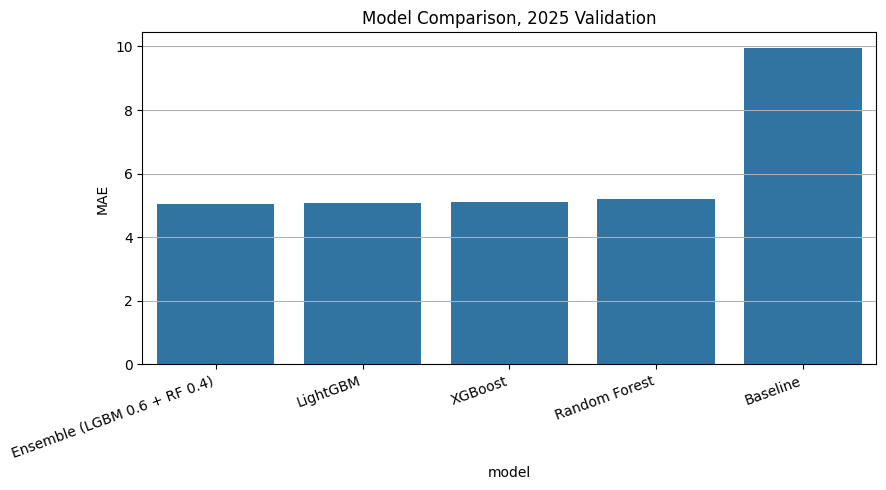

In [17]:
results_rows = [
    {"model": "Baseline",      "MAE": baseline_mae, "RMSE": baseline_rmse, "R2": baseline_r2},
    {"model": "Random Forest", "MAE": rf_mae,        "RMSE": rf_rmse,       "R2": rf_r2},
]
if XGBOOST_AVAILABLE:
    results_rows.append({"model": "XGBoost",  "MAE": xgb_mae,  "RMSE": xgb_rmse,  "R2": xgb_r2})
if LIGHTGBM_AVAILABLE:
    results_rows.append({"model": "LightGBM", "MAE": lgbm_mae, "RMSE": lgbm_rmse, "R2": lgbm_r2})
    results_rows.append({"model": f"Ensemble (LGBM {best_w:.1f} + RF {1-best_w:.1f})",
                          "MAE": ens_mae, "RMSE": ens_rmse, "R2": ens_r2})

results_df = pd.DataFrame(results_rows).sort_values("MAE").reset_index(drop=True)
display(results_df)

plt.figure(figsize=(9, 5))
sns.barplot(data=results_df, x="model", y="MAE")
plt.title("Model Comparison, 2025 Validation")
plt.ylabel("MAE")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

results_df.to_csv(f"{results_dir}/model_comparison_2025_validation.csv", index=False)

the above figure shows how well different models predicts bicycle counts on the 2025 validation dataset   
the y axis shows the mean abslute error, low MAE is better because it means the models predictions are closer to the real bicycle counts. the main patterns is clear: all machine learning perform much better than the baseline. The baseline has an error close to 1o while the machine learning model have error around 5, this means that ML model reduce the average prediction error by almost half. Among the ML models ensemble model perfroms slightly best, followed very closely by lightGBM,XGBoost and random forest.

## 14. Feature importance

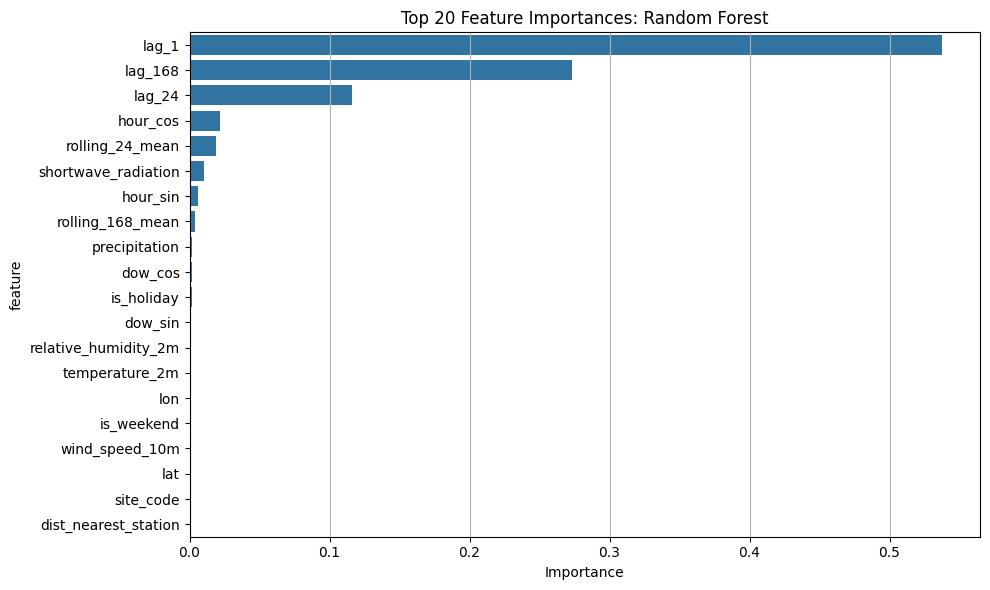

,feature,importance
10,lag_1,0.537710
12,lag_168,0.273189
11,lag_24,0.116358
5,hour_cos,0.021837
13,rolling_24_mean,0.019201
25,shortwave_radiation,0.010473
4,hour_sin,0.005928
14,rolling_168_mean,0.004129
23,precipitation,0.001851
7,dow_cos,0.001632


In [18]:
importance_df = (
    pd.DataFrame({"feature": feature_cols, "importance": rf_model.feature_importances_})
    .sort_values("importance", ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(20), x="importance", y="feature")
plt.title("Top 20 Feature Importances: Random Forest")
plt.xlabel("Importance")
plt.grid(axis="x")
plt.tight_layout()
plt.show()

display(importance_df.head(20))

Feature-importance analysis showed that the Random Forest model was mainly driven by lag-based bicycle-count variables. The previous count (lag_1) was the strongest predictor, followed by weekly and daily lag variables (lag_168 and lag_24). This indicates that bicycle traffic is highly autoregressive and follows strong daily and weekly patterns. Time-of-day variables, rolling averages, weather variables, and enriched spatial features contributed less strongly, suggesting that they provide additional contextual information but that recent historical bicycle-count behavior is the dominant signal for prediction.

## 15. 2025 Validation diagnostics

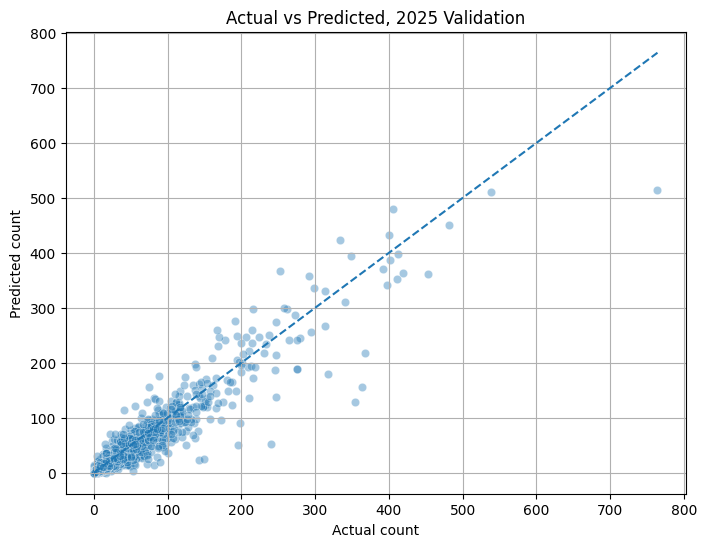

In [19]:
val_results = val_df_model.copy()
val_results["actual_count"]    = y_val_original
val_results["predicted_count"] = ensemble_pred
val_results["residual"]        = val_results["actual_count"] - val_results["predicted_count"]
val_results["absolute_error"]  = val_results["residual"].abs()

sample_plot = val_results.sample(min(5000, len(val_results)), random_state=42)
plt.figure(figsize=(8, 6))
sns.scatterplot(data=sample_plot, x="actual_count", y="predicted_count", alpha=0.4)
max_val = max(sample_plot["actual_count"].max(), sample_plot["predicted_count"].max())
plt.plot([0, max_val], [0, max_val], linestyle="--")
plt.title("Actual vs Predicted, 2025 Validation")
plt.xlabel("Actual count")
plt.ylabel("Predicted count")
plt.grid(True)
plt.show()

the plot compares the actual cycling counts with model predicted counts for 2025 validation data, most points are close to the dashed diagonal line meaning the model predicts the low and medium cycling counts and reasonably well. however for very high actual counts many points fall below the line showing that model tends to underpredict peak cycling activity especially at busy sites.

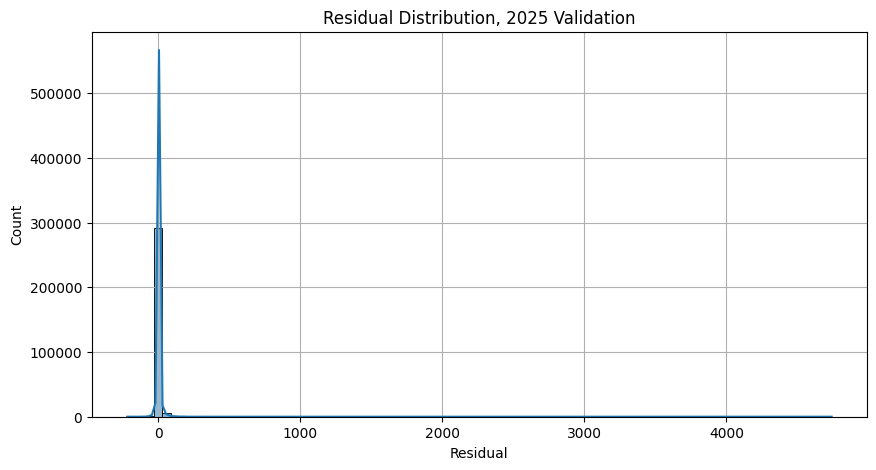

In [20]:
plt.figure(figsize=(10, 5))
sns.histplot(val_results["residual"], bins=80, kde=True)
plt.title("Residual Distribution, 2025 Validation")
plt.xlabel("Residual")
plt.grid(True)
plt.show()

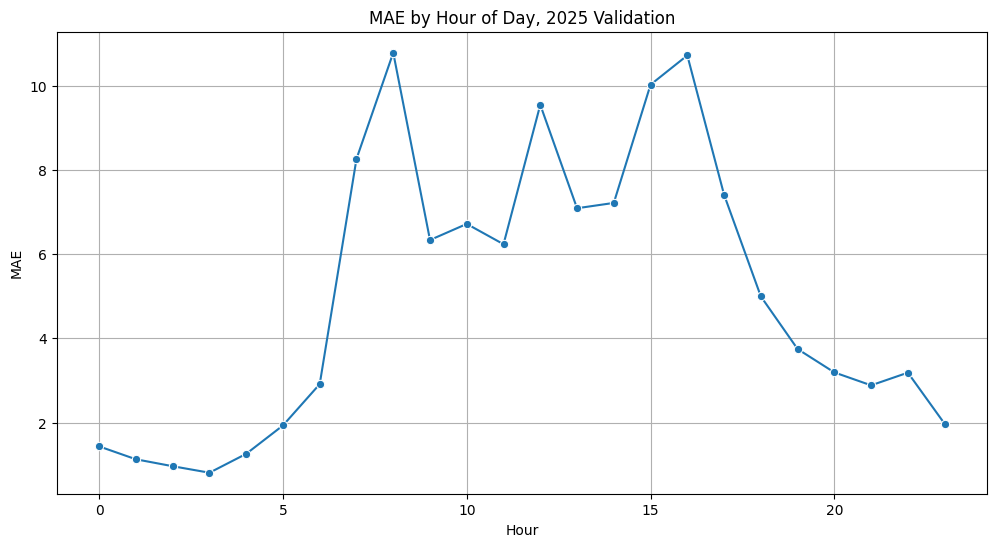

In [21]:
hourly_error = (
    val_results.groupby("hour")
    .agg(mean_actual=("actual_count", "mean"),
         mean_predicted=("predicted_count", "mean"),
         mean_absolute_error=("absolute_error", "mean"))
    .reset_index()
)
plt.figure(figsize=(12, 6))
sns.lineplot(data=hourly_error, x="hour", y="mean_absolute_error", marker="o")
plt.title("MAE by Hour of Day, 2025 Validation")
plt.xlabel("Hour")
plt.ylabel("MAE")
plt.grid(True)
plt.show()

This plot shows that the model makes the smallest errors during the night and early morning, when cycling counts are low and more predictable. The error increases strongly during commuting and active travel hours, especially around 7–8 AM and 15–16 PM, where cycling demand changes quickly and peak counts are harder to predict. This means the model performs well for low-demand periods but still struggles with high-activity peak hours, which are the most important periods for forecasting

## 16. Observed vs forecast weather comparison

RF with observed weather: MAE=6.663  RMSE=17.411  R²=0.916
RF with forecast weather: MAE=6.675  RMSE=17.401  R²=0.916


,model,MAE,RMSE,R2
0,RF with observed weather,6.663,17.411,0.916
1,RF with forecast weather,6.675,17.401,0.916


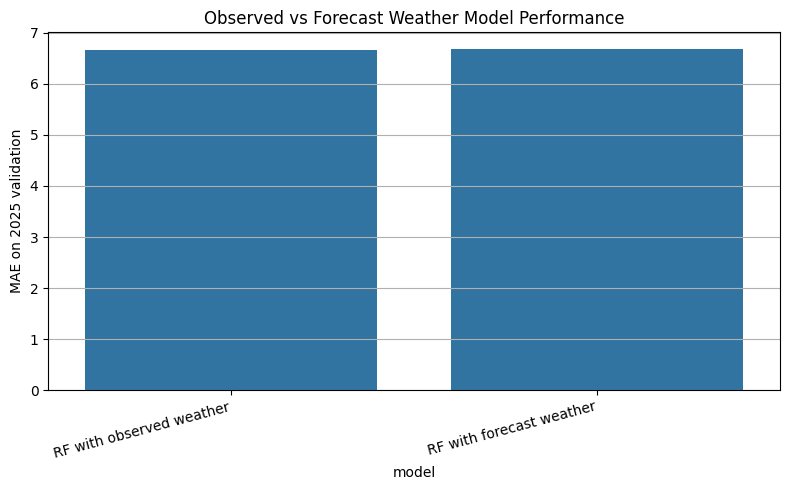

In [24]:
weather_forecast = parse_weather(forecast_weather_path, [2024, 2025])
forecast_meta    = pd.read_csv(forecast_metadata_path)

if "Unnamed: 0" in forecast_meta.columns:
    forecast_meta = forecast_meta.drop(columns=["Unnamed: 0"])
if "timezone" in forecast_meta.columns:
    forecast_meta["timezone"] = (
        forecast_meta["timezone"].astype(str)
        .str.replace("b'", "", regex=False)
        .str.replace("'", "", regex=False)
    )
forecast_meta["site_id"] = pd.to_numeric(forecast_meta["site_id"], errors="coerce")
forecast_meta = forecast_meta.sort_values("site_id").drop_duplicates(subset=["site_id"]).copy()

forecast_weather_cols = [
    col for col in ["temperature_2m", "precipitation", "wind_speed_10m",
                    "shortwave_radiation", "relative_humidity_2m"]
    if col in weather_forecast.columns
]

weather_forecast["site_id"] = pd.to_numeric(weather_forecast["site_id"], errors="coerce")
weather_forecast_small = (
    weather_forecast[["site_id", "datetime_hour"] + forecast_weather_cols]
    .drop_duplicates(subset=["site_id", "datetime_hour"])
    .copy()
)

df_cycling_hourly_2425["site_id"] = pd.to_numeric(df_cycling_hourly_2425["site_id"], errors="coerce")
df_cycling_hourly_2425["datetime_hour"] = pd.to_datetime(df_cycling_hourly_2425["datetime_hour"], errors="coerce")

df_forecast_weather_raw = df_cycling_hourly_2425.merge(
    weather_forecast_small, on=["site_id", "datetime_hour"], how="inner"
)
df_forecast_weather_raw["site_id"] = pd.to_numeric(df_forecast_weather_raw["site_id"], errors="coerce")
df_forecast_weather_raw = df_forecast_weather_raw.merge(enriched_sites_clean, on="site_id", how="left")

for col in ["school_count", "park_count", "station_count"]:
    if col in df_forecast_weather_raw.columns:
        df_forecast_weather_raw[col] = df_forecast_weather_raw[col].fillna(0)

df_forecast_weather_raw = impute_distances(df_forecast_weather_raw, distance_cols)
df_forecast_weather_raw, _ = add_features(df_forecast_weather_raw, site_to_code)
df_forecast_weather_raw = df_forecast_weather_raw.loc[:, ~df_forecast_weather_raw.columns.duplicated()].copy()

key_cols       = ["site_id", "datetime_hour"]
forecast_keys  = df_forecast_weather_raw[key_cols].drop_duplicates()
obs_common_raw = model_data.copy()
obs_common_raw["site_id"]       = pd.to_numeric(obs_common_raw["site_id"], errors="coerce")
obs_common_raw["datetime_hour"] = pd.to_datetime(obs_common_raw["datetime_hour"], errors="coerce")
obs_common_raw = obs_common_raw.merge(forecast_keys, on=key_cols, how="inner")

common_feature_cols = [col for col in feature_cols
                       if col in obs_common_raw.columns and col in df_forecast_weather_raw.columns]

observed_common = obs_common_raw.dropna(subset=common_feature_cols + ["count"]).copy()
forecast_common = df_forecast_weather_raw.dropna(subset=common_feature_cols + ["count"]).copy()

common_keys = (
    observed_common[key_cols]
    .merge(forecast_common[key_cols], on=key_cols, how="inner")
    .drop_duplicates()
)
observed_common = observed_common.merge(common_keys, on=key_cols, how="inner")
forecast_common = forecast_common.merge(common_keys, on=key_cols, how="inner")

n_sites_fc = forecast_common["site_id"].nunique()
train_keys_fc = (
    forecast_common[forecast_common["year"] == 2024]
    .sort_values(key_cols).groupby("site_id", group_keys=False)
    .tail(max(1, max_train_rows // n_sites_fc))
    [key_cols].drop_duplicates()
)
val_keys_fc = (
    forecast_common[forecast_common["year"] == 2025]
    .sort_values(key_cols).groupby("site_id", group_keys=False)
    .tail(max(1, max_val_rows // n_sites_fc))
    [key_cols].drop_duplicates()
)

def train_eval_rf_common(data, feat_cols, t_keys, v_keys, label):
    tr  = data.merge(t_keys, on=key_cols, how="inner")
    vl  = data.merge(v_keys, on=key_cols, how="inner")
    rf  = RandomForestRegressor(
        n_estimators=50, max_depth=12, min_samples_leaf=10,
        max_features=0.6, random_state=42, n_jobs=-1
    )
    rf.fit(tr[feat_cols], np.log1p(tr["count"]))
    pred = predict_counts(rf, vl[feat_cols])
    m    = evaluate(vl["count"].values, pred)
    print(f"{label}: MAE={m['MAE']}  RMSE={m['RMSE']}  R²={m['R2']}")
    return {"model": label, **m}

obs_metrics   = train_eval_rf_common(observed_common, common_feature_cols, train_keys_fc, val_keys_fc, "RF with observed weather")
fcast_metrics = train_eval_rf_common(forecast_common, common_feature_cols, train_keys_fc, val_keys_fc, "RF with forecast weather")

weather_comparison_df = pd.DataFrame([obs_metrics, fcast_metrics])
display(weather_comparison_df)

plt.figure(figsize=(8, 5))
sns.barplot(data=weather_comparison_df, x="model", y="MAE")
plt.title("Observed vs Forecast Weather Model Performance")
plt.ylabel("MAE on 2025 validation")
plt.xticks(rotation=15, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

weather_comparison_df.to_csv(f"{results_dir}/observed_vs_forecast_weather_comparison.csv", index=False)

## 17. Final test: train 2024+2025, test 2026

In [25]:
df_cycling_242526 = pd.read_parquet(
    cycling_file,
    columns=available_cols,
    filters=[("year", "in", [2024, 2025, 2026])]
)
df_cycling_242526["count"]         = pd.to_numeric(df_cycling_242526["count"], errors="coerce")
df_cycling_242526["datetime"]      = pd.to_datetime(df_cycling_242526["start_time"], errors="coerce")
df_cycling_242526["datetime_hour"] = df_cycling_242526["datetime"].dt.floor("h")
df_cycling_242526["year"]          = df_cycling_242526["datetime_hour"].dt.year
df_cycling_242526["month"]         = df_cycling_242526["datetime_hour"].dt.month
df_cycling_242526["day"]           = df_cycling_242526["datetime_hour"].dt.day
df_cycling_242526["hour"]          = df_cycling_242526["datetime_hour"].dt.hour
df_cycling_242526["day_of_week"]   = df_cycling_242526["datetime_hour"].dt.dayofweek
df_cycling_242526["is_weekend"]    = df_cycling_242526["day_of_week"].isin([5, 6]).astype(int)
df_cycling_242526 = df_cycling_242526[df_cycling_242526["year"].isin([2024, 2025, 2026])].copy()

df_cycling_hourly_242526 = (
    df_cycling_242526
    .groupby(["site_id", "datetime_hour"])
    .agg(**agg_dict)
    .reset_index()
)
print("Hourly cycling 2024-2026:", df_cycling_hourly_242526.shape)
print(df_cycling_hourly_242526["year"].value_counts().sort_index())

Hourly cycling 2024-2026: (2652293, 13)
year
2024    1209798
2025    1237175
2026     205320
Name: count, dtype: int64


In [26]:
weather_242526 = parse_weather(weather_data, [2024, 2025, 2026])
weather_cols_final = [
    col for col in ["temperature_2m", "precipitation", "wind_speed_10m",
                    "shortwave_radiation", "relative_humidity_2m"]
    if col in weather_242526.columns
]

df_model_242526 = merge_weather_with_cycling(df_cycling_hourly_242526, weather_242526, weather_cols_final)
df_model_242526 = df_model_242526.loc[:, ~df_model_242526.columns.duplicated()].copy()
df_model_242526["site_id"] = pd.to_numeric(df_model_242526["site_id"], errors="coerce")
df_model_242526 = df_model_242526.merge(enriched_sites_clean, on="site_id", how="left")

for col in ["school_count", "park_count", "station_count"]:
    if col in df_model_242526.columns:
        df_model_242526[col] = df_model_242526[col].fillna(0)

df_model_242526 = impute_distances(df_model_242526, distance_cols)

trainval_sites     = sorted(df_model_242526[df_model_242526["year"].isin([2024, 2025])]["site_id"].dropna().unique())
site_to_code_final = {s: i for i, s in enumerate(trainval_sites)}

df_model_242526, _ = add_features(df_model_242526, site_to_code_final)

final_feature_cols = [
    "site_code",
    "is_weekend", "is_holiday", "is_pre_holiday",
    "hour_sin", "hour_cos",
    "dow_sin",  "dow_cos",
    "month_sin", "month_cos",
    "lag_1", "lag_24", "lag_168",
    "rolling_24_mean", "rolling_168_mean",
]
for col in ["lat", "lon"]:
    if col in df_model_242526.columns:
        final_feature_cols.append(col)

enriched_feature_cols_final = [
    col for col in ["school_count", "park_count", "station_count",
                    "dist_nearest_school", "dist_nearest_station"]
    if col in df_model_242526.columns
]
final_feature_cols = list(dict.fromkeys(final_feature_cols + enriched_feature_cols_final + weather_cols_final))

model_data_final = df_model_242526.dropna(subset=final_feature_cols + ["count"]).copy()
trainval_df      = model_data_final[model_data_final["year"].isin([2024, 2025])].copy()
test_2026_df     = model_data_final[model_data_final["year"] == 2026].copy()

print("Trainval 2024+2025:", trainval_df.shape)
print("Test 2026:", test_2026_df.shape)
print("2026 date range:", test_2026_df["datetime_hour"].min(), "→", test_2026_df["datetime_hour"].max())

Before merge: (2652293, 13) → After merge: (2652293, 18)
Trainval 2024+2025: (2421941, 37)
Test 2026: (205320, 37)
2026 date range: 2026-01-01 00:00:00 → 2026-02-28 23:00:00


In [27]:
MAX_TRAINVAL_ROWS = 1_200_000
trainval_model_df = (
    trainval_df.sort_values(["site_id", "datetime_hour"])
    .groupby("site_id", group_keys=False)
    .tail(max(1, MAX_TRAINVAL_ROWS // trainval_df["site_id"].nunique()))
    .copy()
)

known_site_ids = set(site_to_code_final.keys())
known_train    = trainval_model_df[trainval_model_df["site_id"].isin(known_site_ids)].copy()
unknown_train  = trainval_model_df[~trainval_model_df["site_id"].isin(known_site_ids)].copy()
known_test     = test_2026_df[test_2026_df["site_id"].isin(known_site_ids)].copy()
unknown_test   = test_2026_df[~test_2026_df["site_id"].isin(known_site_ids)].copy()

print(f"Known:   train={known_train['site_id'].nunique()} sites  test={known_test['site_id'].nunique()} sites")
print(f"Unknown: train={unknown_train['site_id'].nunique()} sites  test={unknown_test['site_id'].nunique()} sites")

Known:   train=149 sites  test=145 sites
Unknown: train=0 sites  test=0 sites


In [28]:
# Main model (known sites) — RF
final_rf_model = RandomForestRegressor(
    n_estimators=50, max_depth=12, min_samples_leaf=10,
    max_features=0.6, random_state=42, n_jobs=-1
)
final_rf_model.fit(known_train[final_feature_cols], np.log1p(known_train["count"]))
known_rf_pred = predict_counts(final_rf_model, known_test[final_feature_cols])

# Main model (known sites) — LightGBM + ensemble
if LIGHTGBM_AVAILABLE:
    ktr_sorted = known_train.sort_values(["site_id", "datetime_hour"])
    X_ktr, X_kes, y_ktr, y_kes = train_test_split(
        ktr_sorted[final_feature_cols], np.log1p(ktr_sorted["count"]),
        test_size=0.15, shuffle=False
    )
    final_lgbm_model = LGBMRegressor(
        n_estimators=800, learning_rate=0.05, num_leaves=64,
        subsample=0.85, colsample_bytree=0.85, random_state=42, n_jobs=-1
    )
    final_lgbm_model.fit(
        X_ktr, y_ktr,
        eval_set=[(X_kes, y_kes)],
        callbacks=[early_stopping(30), log_evaluation(100)]
    )
    known_lgbm_pred = predict_counts(final_lgbm_model, known_test[final_feature_cols])
    known_pred = best_w * known_lgbm_pred + (1 - best_w) * known_rf_pred
else:
    known_pred = known_rf_pred

# Fallback model (unknown sites)
fallback_feature_cols = [
    col for col in [
        "lat", "lon",
        "hour_sin", "hour_cos", "dow_sin", "dow_cos", "month_sin", "month_cos",
        "is_weekend", "is_holiday", "is_pre_holiday",
        "school_count", "park_count", "station_count",
        "dist_nearest_school", "dist_nearest_station",
        "rolling_24_mean", "rolling_168_mean",
        "lag_1", "lag_24", "lag_168",
    ] + weather_cols_final
    if col in df_model_242526.columns
]

if len(unknown_train) > 0:
    fallback_model = RandomForestRegressor(
        n_estimators=50, max_depth=10, min_samples_leaf=10,
        max_features=0.6, random_state=42, n_jobs=-1
    )
    fallback_model.fit(unknown_train[fallback_feature_cols], np.log1p(unknown_train["count"]))
    unknown_pred = predict_counts(fallback_model, unknown_test[fallback_feature_cols])
else:
    unknown_pred = np.full(len(unknown_test), known_train["count"].mean())

known_test  = known_test.copy()
unknown_test = unknown_test.copy()
known_test["predicted_count"]   = known_pred
unknown_test["predicted_count"] = unknown_pred

test_2026_results = (
    pd.concat([known_test, unknown_test])
    .sort_values(["site_id", "datetime_hour"])
)
test_2026_results["actual_count"]   = test_2026_results["count"]
test_2026_results["residual"]       = test_2026_results["actual_count"] - test_2026_results["predicted_count"]
test_2026_results["absolute_error"] = test_2026_results["residual"].abs()

for label, subset in [
    ("All sites",     test_2026_results),
    ("Known sites",   test_2026_results[test_2026_results["site_id"].isin(known_site_ids)]),
    ("Unknown sites", test_2026_results[~test_2026_results["site_id"].isin(known_site_ids)]),
]:
    if len(subset) == 0:
        continue
    m = evaluate(subset["actual_count"], subset["predicted_count"])
    print(f"{label}: MAE={m['MAE']}  RMSE={m['RMSE']}  R²={m['R2']}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009738 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3037
[LightGBM] [Info] Number of data points in the train set: 983454, number of used features: 27
[LightGBM] [Info] Start training from score 2.146840
Training until validation scores don't improve for 30 rounds
[100]	valid_0's l2: 0.210437
[200]	valid_0's l2: 0.20393
Early stopping, best iteration is:
[178]	valid_0's l2: 0.203571
All sites: MAE=4.712  RMSE=12.561  R²=0.89
Known sites: MAE=4.712  RMSE=12.561  R²=0.89


## 18. 2026 Test diagnostics

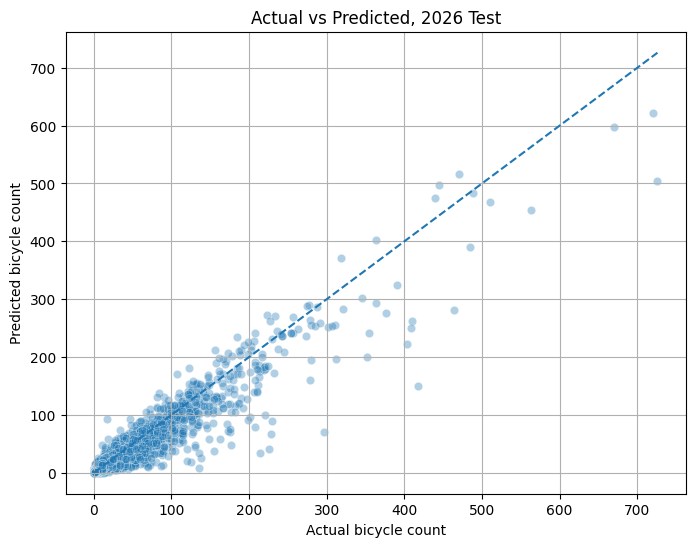

In [29]:
sample_2026 = test_2026_results.sample(min(10000, len(test_2026_results)), random_state=42)
plt.figure(figsize=(8, 6))
sns.scatterplot(data=sample_2026, x="actual_count", y="predicted_count", alpha=0.35)
max_val = max(sample_2026["actual_count"].max(), sample_2026["predicted_count"].max())
plt.plot([0, max_val], [0, max_val], linestyle="--")
plt.title("Actual vs Predicted, 2026 Test")
plt.xlabel("Actual bicycle count")
plt.ylabel("Predicted bicycle count")
plt.grid(True)
plt.show()

This plot shows the model’s performance on the 2026 test data, comparing actual bicycle counts with predicted counts. Most points are close to the dashed diagonal line, meaning the model predicts low and medium cycling counts reasonably well. However, for very high actual counts, several points fall below the line, showing that the model still tends to underpredict peak cycling demand, especially at very busy sites or high-activity hours.

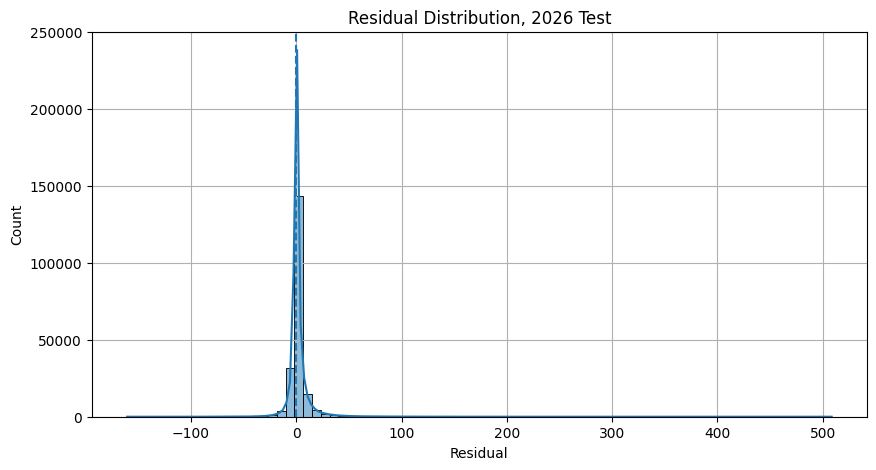

In [30]:
plt.figure(figsize=(10, 5))
sns.histplot(test_2026_results["residual"], bins=80, kde=True)
plt.axvline(0, linestyle="--")
plt.title("Residual Distribution, 2026 Test")
plt.xlabel("Residual")
plt.grid(True)
plt.show()

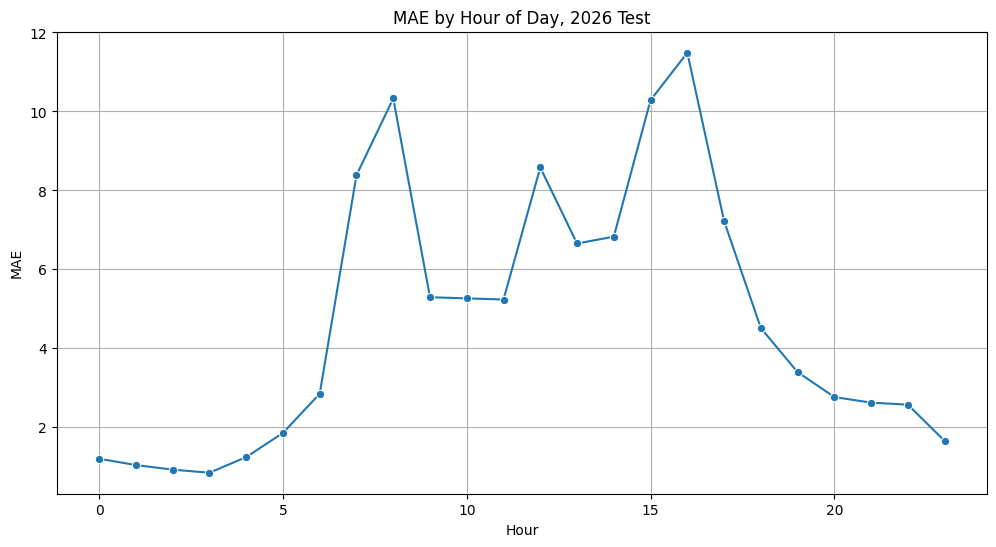

In [31]:
hourly_error_2026 = (
    test_2026_results.groupby("hour")
    .agg(mean_actual=("actual_count", "mean"),
         mean_predicted=("predicted_count", "mean"),
         mean_absolute_error=("absolute_error", "mean"))
    .reset_index()
)
plt.figure(figsize=(12, 6))
sns.lineplot(data=hourly_error_2026, x="hour", y="mean_absolute_error", marker="o")
plt.title("MAE by Hour of Day, 2026 Test")
plt.xlabel("Hour")
plt.ylabel("MAE")
plt.grid(True)
plt.show()

,site_id,n_records,mean_actual,mean_predicted,mean_absolute_error,max_absolute_error
136,143,1416,152.582626,139.261568,31.455186,508.427251
103,107,1416,159.127823,147.567439,27.716551,316.895792
121,125,1416,71.302963,62.694616,19.803034,391.772881
105,109,1416,62.670902,55.236013,17.025543,244.926479
67,69,1416,95.191383,88.919326,16.289790,245.431122
135,140,1416,67.026833,60.474660,14.960518,200.773783
132,137,1416,64.701271,59.621244,14.771146,195.308080
133,138,1416,58.583332,53.210762,12.281400,148.879892
96,100,1416,56.283897,52.769925,10.106053,139.856502
87,89,1416,27.512712,23.051179,9.842317,211.531352


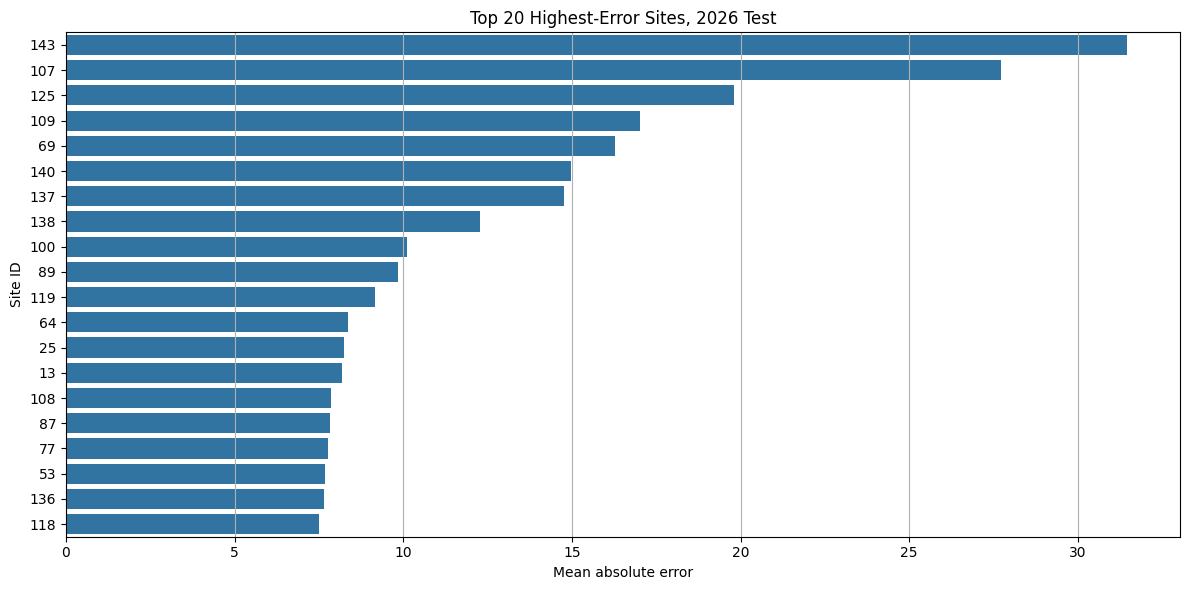

In [32]:
site_error_2026 = (
    test_2026_results.groupby("site_id")
    .agg(n_records=("actual_count", "size"),
         mean_actual=("actual_count", "mean"),
         mean_predicted=("predicted_count", "mean"),
         mean_absolute_error=("absolute_error", "mean"),
         max_absolute_error=("absolute_error", "max"))
    .reset_index()
    .sort_values("mean_absolute_error", ascending=False)
)
display(site_error_2026.head(20))

top_sites = site_error_2026.head(20).copy()
top_sites["site_id"] = top_sites["site_id"].astype(str)
plt.figure(figsize=(12, 6))
sns.barplot(data=top_sites, x="mean_absolute_error", y="site_id", orient="h")
plt.title("Top 20 Highest-Error Sites, 2026 Test")
plt.xlabel("Mean absolute error")
plt.ylabel("Site ID")
plt.grid(axis="x")
plt.tight_layout()
plt.show()

## 19. Final summary & save all results

,stage,MAE,RMSE,R2
0,2025 val — RF,5.203,15.889,0.867
1,2025 val — Ensemble,5.033,15.628,0.871
2,2026 test — Ensemble,4.712,12.561,0.89
3,CV RF mean ± std,6.036±1.113,—,0.804
4,CV Ens mean ± std,5.940±1.215,—,0.806


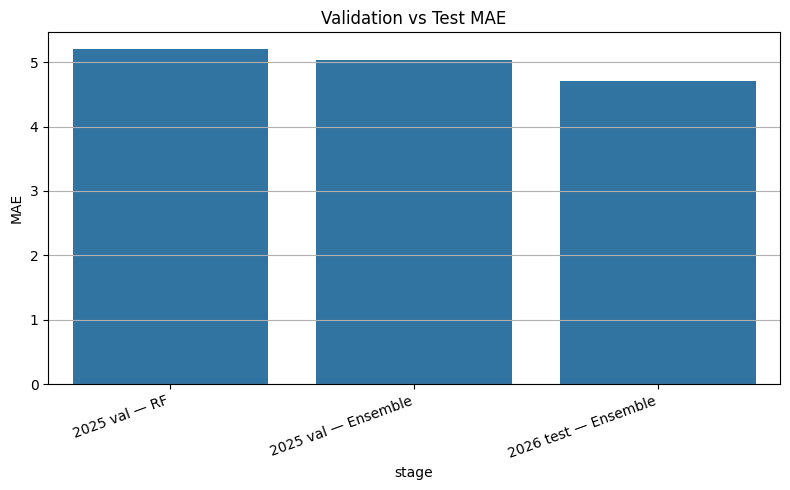

In [33]:
final_mae  = mean_absolute_error(test_2026_results["actual_count"], test_2026_results["predicted_count"])
final_rmse = np.sqrt(mean_squared_error(test_2026_results["actual_count"], test_2026_results["predicted_count"]))
final_r2   = r2_score(test_2026_results["actual_count"], test_2026_results["predicted_count"])

summary_rows = [
    {"stage": "2025 val — RF",        "MAE": rf_mae,               "RMSE": rf_rmse,               "R2": rf_r2},
    {"stage": "2025 val — Ensemble",   "MAE": ens_mae,              "RMSE": ens_rmse,              "R2": ens_r2},
    {"stage": "2026 test — Ensemble",  "MAE": round(final_mae, 3),  "RMSE": round(final_rmse, 3),  "R2": round(final_r2, 3)},
    {"stage": "CV RF mean ± std",      "MAE": f"{cv_df['RF_MAE'].mean():.3f}±{cv_df['RF_MAE'].std():.3f}", "RMSE": "—", "R2": f"{cv_df['RF_R2'].mean():.3f}"},
]
if LIGHTGBM_AVAILABLE:
    summary_rows.append({
        "stage": "CV Ens mean ± std",
        "MAE":  f"{cv_df['Ens_MAE'].mean():.3f}±{cv_df['Ens_MAE'].std():.3f}",
        "RMSE": "—",
        "R2":   f"{cv_df['Ens_R2'].mean():.3f}",
    })

final_summary = pd.DataFrame(summary_rows)
display(final_summary)

numeric_rows = final_summary[final_summary["MAE"].apply(lambda x: isinstance(x, float))].copy()
plt.figure(figsize=(8, 5))
sns.barplot(data=numeric_rows, x="stage", y="MAE")
plt.title("Validation vs Test MAE")
plt.ylabel("MAE")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

The validation and test MAE comparison shows that the ensemble model reduces prediction error compared with the Random Forest baseline. The final 2026 test MAE is lower than the 2025 validation MAE, suggesting that training on both 2024 and 2025 improved the model’s ability to predict future cycling counts

In [34]:
df_model_2425[weather_cols].isna().mean()

,0
temperature_2m,0.0
precipitation,0.0
wind_speed_10m,0.0
shortwave_radiation,0.0
relative_humidity_2m,0.0


In [35]:
test_2026_results.to_csv(f"{results_dir}/final_2026_predictions.csv", index=False)
cv_df.to_csv(f"{results_dir}/walk_forward_cv_results.csv", index=False)
final_summary.to_csv(f"{results_dir}/final_summary_metrics.csv", index=False)
weather_comparison_df.to_csv(f"{results_dir}/observed_vs_forecast_weather_comparison.csv", index=False)
results_df.to_csv(f"{results_dir}/model_comparison_2025_validation.csv", index=False)

print("Saved to:", results_dir)
print("  final_2026_predictions.csv")
print("  walk_forward_cv_results.csv")
print("  final_summary_metrics.csv")
print("  observed_vs_forecast_weather_comparison.csv")
print("  model_comparison_2025_validation.csv")

Saved to: /content/drive/MyDrive/Colab Notebooks/results
  final_2026_predictions.csv
  walk_forward_cv_results.csv
  final_summary_metrics.csv
  observed_vs_forecast_weather_comparison.csv
  model_comparison_2025_validation.csv


In [36]:
IMPACT_CONSTANTS = {
    # Fraction of counted cyclists who replaced a car trip
    # Belgian modal shift studies: 30-40%; use 0.35 as central estimate
    "modal_shift_rate": 0.35,

    # Average cycling trip length in km
    # Urban sites ~2.5km, commuter routes ~6km; 4km is a reasonable network average
    "avg_trip_km": 4.0,

    # CO2 emitted per km by average Belgian car (grams)
    "co2_per_km_g": 120,

    # Fuel consumed per km (litres)
    "fuel_per_km_l": 0.07,

    # Retail fuel price (€/litre)
    "fuel_price_eur": 1.75,

    # Calories burned per km of cycling
    "kcal_per_km": 40,

    # External health cost of car pollution per km (€)
    # Covers air pollution + noise; EU external cost estimates
    "health_cost_per_km_eur": 0.03,

    # EU carbon market price per tonne of CO2 (€)
    "co2_price_per_tonne_eur": 65,
}

print("Impact constants loaded.")
print(f"  Modal shift rate : {IMPACT_CONSTANTS['modal_shift_rate']*100:.0f}%")
print(f"  Avg trip length  : {IMPACT_CONSTANTS['avg_trip_km']} km")
print(f"  CO2 per car-km   : {IMPACT_CONSTANTS['co2_per_km_g']} g")
print(f"  Carbon price     : €{IMPACT_CONSTANTS['co2_price_per_tonne_eur']}/tonne")

Impact constants loaded.
  Modal shift rate : 35%
  Avg trip length  : 4.0 km
  CO2 per car-km   : 120 g
  Carbon price     : €65/tonne


In [ ]:
def compute_impact(df, constants=IMPACT_CONSTANTS, site_avg_km=None):

    df = df.copy()

    # Per-site trip distance if provided, else network average
    if site_avg_km is not None:
        df = df.merge(site_avg_km, on="site_id", how="left")
        df["avg_trip_km"] = df["avg_trip_km"].fillna(constants["avg_trip_km"])
    else:
        df["avg_trip_km"] = constants["avg_trip_km"]

    # Car trips replaced
    df["car_trips_replaced"] = (
        df["predicted_count"] * constants["modal_shift_rate"]
    ).round(2)

    # Distance not driven by car
    df["km_not_driven"] = (
        df["car_trips_replaced"] * df["avg_trip_km"]
    ).round(2)

    # CO2 saved (kg)
    df["co2_saved_kg"] = (
        df["km_not_driven"] * constants["co2_per_km_g"] / 1000
    ).round(3)

    # Fuel saved (litres)
    df["fuel_saved_litres"] = (
        df["km_not_driven"] * constants["fuel_per_km_l"]
    ).round(3)

    # Fuel cost saved (€)
    df["fuel_cost_saved_eur"] = (
        df["fuel_saved_litres"] * constants["fuel_price_eur"]
    ).round(3)

    # Carbon credit value (€)
    df["carbon_value_eur"] = (
        df["co2_saved_kg"] / 1000 * constants["co2_price_per_tonne_eur"]
    ).round(4)

    # Calories burned by cyclists
    df["kcal_burned"] = (
        df["predicted_count"] * df["avg_trip_km"] * constants["kcal_per_km"]
    ).round(0)

    # External health cost avoided (€)
    df["health_cost_avoided_eur"] = (
        df["km_not_driven"] * constants["health_cost_per_km_eur"]
    ).round(3)

    # Total monetary value (€)
    df["total_value_eur"] = (
        df["fuel_cost_saved_eur"] +
        df["carbon_value_eur"] +
        df["health_cost_avoided_eur"]
    ).round(3)

    return df

print("compute_impact() defined.")

compute_impact() defined.


In [ ]:
# test_2026_results already has predicted_count from section 17
impact_df = compute_impact(test_2026_results)

impact_cols = [
    "site_id", "datetime_hour", "hour", "predicted_count",
    "car_trips_replaced", "km_not_driven",
    "co2_saved_kg", "fuel_saved_litres",
    "fuel_cost_saved_eur", "carbon_value_eur",
    "health_cost_avoided_eur", "total_value_eur", "kcal_burned"
]

print("Impact columns added:")
display(impact_df[impact_cols].head(10))

Impact columns added:


,site_id,datetime_hour,hour,predicted_count,car_trips_replaced,km_not_driven,co2_saved_kg,fuel_saved_litres,fuel_cost_saved_eur,carbon_value_eur,health_cost_avoided_eur,total_value_eur,kcal_burned
17544,1,2026-01-01 00:00:00,0,0.419302,0.15,0.60,0.072,0.042,0.074,0.0047,0.018,0.097,67.0
17545,1,2026-01-01 01:00:00,1,1.258577,0.44,1.76,0.211,0.123,0.215,0.0137,0.053,0.282,201.0
17546,1,2026-01-01 02:00:00,2,0.672360,0.24,0.96,0.115,0.067,0.117,0.0075,0.029,0.154,108.0
17547,1,2026-01-01 03:00:00,3,0.817200,0.29,1.16,0.139,0.081,0.142,0.0090,0.035,0.186,131.0
17548,1,2026-01-01 04:00:00,4,0.692364,0.24,0.96,0.115,0.067,0.117,0.0075,0.029,0.154,111.0
17549,1,2026-01-01 05:00:00,5,2.340604,0.82,3.28,0.394,0.230,0.402,0.0256,0.098,0.526,374.0
17550,1,2026-01-01 06:00:00,6,1.874050,0.66,2.64,0.317,0.185,0.324,0.0206,0.079,0.424,300.0
17551,1,2026-01-01 07:00:00,7,2.831399,0.99,3.96,0.475,0.277,0.485,0.0309,0.119,0.635,453.0
17552,1,2026-01-01 08:00:00,8,1.916576,0.67,2.68,0.322,0.188,0.329,0.0209,0.080,0.430,307.0
17553,1,2026-01-01 09:00:00,9,2.033293,0.71,2.84,0.341,0.199,0.348,0.0222,0.085,0.455,325.0


In [39]:
daily_impact = (
    impact_df
    .groupby(impact_df["datetime_hour"].dt.date)
    .agg(
        total_cyclists      = ("predicted_count",      "sum"),
        car_trips_replaced  = ("car_trips_replaced",   "sum"),
        km_not_driven       = ("km_not_driven",        "sum"),
        co2_saved_kg        = ("co2_saved_kg",         "sum"),
        fuel_saved_litres   = ("fuel_saved_litres",    "sum"),
        fuel_cost_saved_eur = ("fuel_cost_saved_eur",  "sum"),
        carbon_value_eur    = ("carbon_value_eur",     "sum"),
        health_cost_avoided = ("health_cost_avoided_eur", "sum"),
        total_value_eur     = ("total_value_eur",      "sum"),
        kcal_burned         = ("kcal_burned",          "sum"),
    )
    .reset_index()
    .rename(columns={"datetime_hour": "date"})
)

daily_impact["co2_saved_tonnes"] = (daily_impact["co2_saved_kg"] / 1000).round(2)

print("Daily impact shape:", daily_impact.shape)
display(daily_impact.head(10))

Daily impact shape: (59, 12)


,date,total_cyclists,car_trips_replaced,km_not_driven,co2_saved_kg,fuel_saved_litres,fuel_cost_saved_eur,carbon_value_eur,health_cost_avoided,total_value_eur,kcal_burned,co2_saved_tonnes
0,2026-01-01,13920.869052,4872.34,19489.36,2338.746,1364.278,2387.459,152.0182,584.658,3124.142,2227318.0,2.34
1,2026-01-02,22559.747433,7896.06,31584.24,3790.107,2210.895,3869.039,246.3572,947.529,5062.930,3609568.0,3.79
2,2026-01-03,18983.808665,6643.99,26575.96,3189.114,1860.316,3255.552,207.2958,797.280,4260.138,3037408.0,3.19
3,2026-01-04,16600.073017,5809.86,23239.44,2788.767,1626.795,2846.835,181.2701,697.149,3725.265,2656001.0,2.79
4,2026-01-05,31627.143332,11069.67,44278.68,5313.443,3099.509,5424.083,345.3767,1328.359,7097.852,5060350.0,5.31
5,2026-01-06,40883.635903,14309.32,57237.28,6868.497,4006.633,7011.489,446.4531,1717.095,9175.038,6541368.0,6.87
6,2026-01-07,26934.887272,9427.43,37709.72,4525.179,2639.693,4619.378,294.1392,1131.279,6044.806,4309574.0,4.53
7,2026-01-08,25472.940433,8915.41,35661.64,4279.429,2496.347,4368.536,278.1645,1069.817,5716.517,4075680.0,4.28
8,2026-01-09,24658.410084,8630.53,34522.12,4142.668,2416.562,4228.859,269.2775,1035.650,5533.821,3945353.0,4.14
9,2026-01-10,16275.316087,5696.45,22785.80,2734.278,1594.988,2791.178,177.7277,683.592,3652.551,2604051.0,2.73


In [40]:
site_impact = (
    impact_df
    .groupby("site_id")
    .agg(
        total_cyclists      = ("predicted_count",      "sum"),
        car_trips_replaced  = ("car_trips_replaced",   "sum"),
        co2_saved_kg        = ("co2_saved_kg",         "sum"),
        fuel_cost_saved_eur = ("fuel_cost_saved_eur",  "sum"),
        total_value_eur     = ("total_value_eur",      "sum"),
        kcal_burned         = ("kcal_burned",          "sum"),
        hours_counted       = ("predicted_count",      "count"),
    )
    .reset_index()
    .sort_values("co2_saved_kg", ascending=False)
    .reset_index(drop=True)
)

site_impact["co2_saved_tonnes"] = (site_impact["co2_saved_kg"] / 1000).round(2)
site_impact["rank"]             = site_impact.index + 1

print("Top 10 sites by CO2 saved:")
display(site_impact[["rank", "site_id", "total_cyclists",
                      "co2_saved_tonnes", "total_value_eur"]].head(10))

Top 10 sites by CO2 saved:


,rank,site_id,total_cyclists,co2_saved_tonnes,total_value_eur
0,1,107,208955.493939,35.10,46893.956
1,2,143,197194.380741,33.13,44254.340
2,3,69,125909.766267,21.15,28256.618
3,4,125,88775.576223,14.91,19922.981
4,5,140,85632.118192,14.39,19217.562
5,6,137,84423.682212,14.18,18946.462
6,7,109,78214.194928,13.14,17552.960
7,8,138,75346.439295,12.66,16909.158
8,9,100,74722.213525,12.55,16769.209
9,10,119,57374.311403,9.64,12876.010


In [41]:
yearly_impact = (
    impact_df
    .groupby(impact_df["datetime_hour"].dt.year)
    .agg(
        total_cyclists      = ("predicted_count",      "sum"),
        car_trips_replaced  = ("car_trips_replaced",   "sum"),
        km_not_driven       = ("km_not_driven",        "sum"),
        co2_saved_tonnes    = ("co2_saved_kg",    lambda x: round(x.sum() / 1000, 1)),
        fuel_saved_litres   = ("fuel_saved_litres",    "sum"),
        fuel_cost_saved_eur = ("fuel_cost_saved_eur",  "sum"),
        carbon_value_eur    = ("carbon_value_eur",     "sum"),
        health_cost_avoided = ("health_cost_avoided_eur", "sum"),
        total_value_eur     = ("total_value_eur",      "sum"),
        kcal_burned         = ("kcal_burned",          "sum"),
    )
    .reset_index()
    .rename(columns={"datetime_hour": "year"})
)

print("Yearly impact summary:")
display(yearly_impact)

y = yearly_impact.iloc[0]
print(f"\nHeadline numbers for {int(y['year'])}:")
print(f"  Cyclists counted      : {y['total_cyclists']:,.0f}")
print(f"  Car trips replaced    : {y['car_trips_replaced']:,.0f}")
print(f"  CO2 saved             : {y['co2_saved_tonnes']:,.1f} tonnes")
print(f"  Fuel saved            : {y['fuel_saved_litres']:,.0f} litres")
print(f"  Total monetary value  : €{y['total_value_eur']:,.0f}")
print(f"  Calories burned       : {y['kcal_burned']:,.0f} kcal")

Yearly impact summary:


,year,total_cyclists,car_trips_replaced,km_not_driven,co2_saved_tonnes,fuel_saved_litres,fuel_cost_saved_eur,carbon_value_eur,health_cost_avoided,total_value_eur,kcal_burned
0,2026,2.947309e+06,1031554.73,4126218.92,495.1,288835.849,505459.29,32184.5757,123786.043,661429.795,471569558.0



Headline numbers for 2026:
  Cyclists counted      : 2,947,309
  Car trips replaced    : 1,031,555
  CO2 saved             : 495.1 tonnes
  Fuel saved            : 288,836 litres
  Total monetary value  : €661,430
  Calories burned       : 471,569,558 kcal


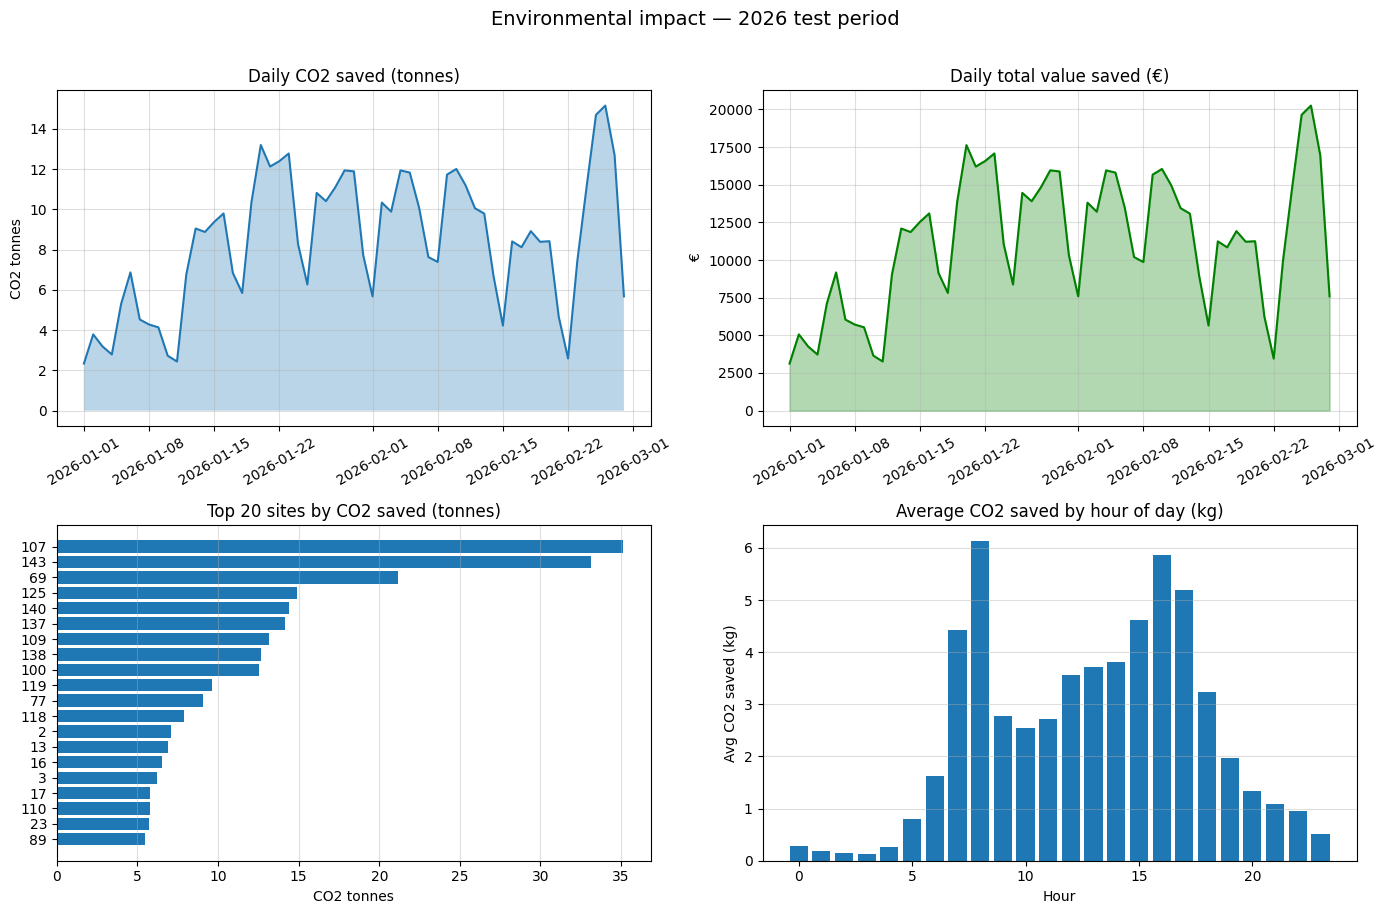

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Daily CO2 savings
ax = axes[0, 0]
ax.fill_between(daily_impact["date"], daily_impact["co2_saved_tonnes"], alpha=0.3)
ax.plot(daily_impact["date"], daily_impact["co2_saved_tonnes"])
ax.set_title("Daily CO2 saved (tonnes)")
ax.set_ylabel("CO2 tonnes")
ax.tick_params(axis="x", rotation=30)
ax.grid(True, alpha=0.4)

# Daily total monetary value
ax = axes[0, 1]
ax.fill_between(daily_impact["date"], daily_impact["total_value_eur"], alpha=0.3, color="green")
ax.plot(daily_impact["date"], daily_impact["total_value_eur"], color="green")
ax.set_title("Daily total value saved (€)")
ax.set_ylabel("€")
ax.tick_params(axis="x", rotation=30)
ax.grid(True, alpha=0.4)

# Top 20 sites by CO2
ax = axes[1, 0]
top20 = site_impact.head(20).copy()
top20["site_id"] = top20["site_id"].astype(str)
ax.barh(top20["site_id"][::-1], top20["co2_saved_tonnes"][::-1])
ax.set_title("Top 20 sites by CO2 saved (tonnes)")
ax.set_xlabel("CO2 tonnes")
ax.grid(axis="x", alpha=0.4)

# Daily CO2 by hour of day
ax = axes[1, 1]
hourly_co2 = (
    impact_df.groupby("hour")["co2_saved_kg"].mean().reset_index()
)
ax.bar(hourly_co2["hour"], hourly_co2["co2_saved_kg"])
ax.set_title("Average CO2 saved by hour of day (kg)")
ax.set_xlabel("Hour")
ax.set_ylabel("Avg CO2 saved (kg)")
ax.grid(axis="y", alpha=0.4)

plt.suptitle("Environmental impact — 2026 test period", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

This figure summarizes the environmental impact estimated from the 2026
test-period cycling predictions. The daily plots show that higher predicted cycling activity leads to higher CO₂ savings and higher monetary value saved, with clear peaks on high-demand days in mid/late January and late February.

The site-level bar chart shows that a small number of sites contribute most to the total CO₂ savings, meaning these locations are especially important for environmental benefit. The hourly chart shows the largest CO₂ savings during peak cycling hours, especially around 8 AM and 16–17 PM, which matches commuting patterns and suggests that cycling during rush hours has the strongest potential impact.

In [43]:
import plotly.express as px

# Merge lat/lon into site impact
site_coords = (
    test_2026_results[["site_id", "lat", "lon"]]
    .drop_duplicates("site_id")
    .dropna(subset=["lat", "lon"])
)

site_impact_map = site_impact.merge(site_coords, on="site_id", how="left").dropna(subset=["lat", "lon"])

fig = px.scatter_mapbox(
    site_impact_map,
    lat="lat",
    lon="lon",
    color="co2_saved_tonnes",
    size="total_cyclists",
    size_max=30,
    hover_name="site_id",
    hover_data={
        "total_cyclists":      ":,.0f",
        "co2_saved_tonnes":    ":.2f",
        "total_value_eur":     ":,.0f",
        "fuel_cost_saved_eur": ":,.0f",
        "lat": False,
        "lon": False,
    },
    color_continuous_scale="Reds",
    zoom=9,
    height=600,
    title="CO2 saved per site — 2026 (bubble size = total cyclists)"
)
fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(margin={"r": 0, "t": 50, "l": 0, "b": 0})
fig.show()

,modal_shift_rate,co2_saved_tonnes,total_value_eur
0,15%,212.2,283472.0
1,20%,282.9,377963.0
2,25%,353.7,472454.0
3,30%,424.4,566944.0
4,35%,495.1,661435.0
5,40%,565.9,755926.0
6,45%,636.6,850417.0
7,50%,707.4,944907.0


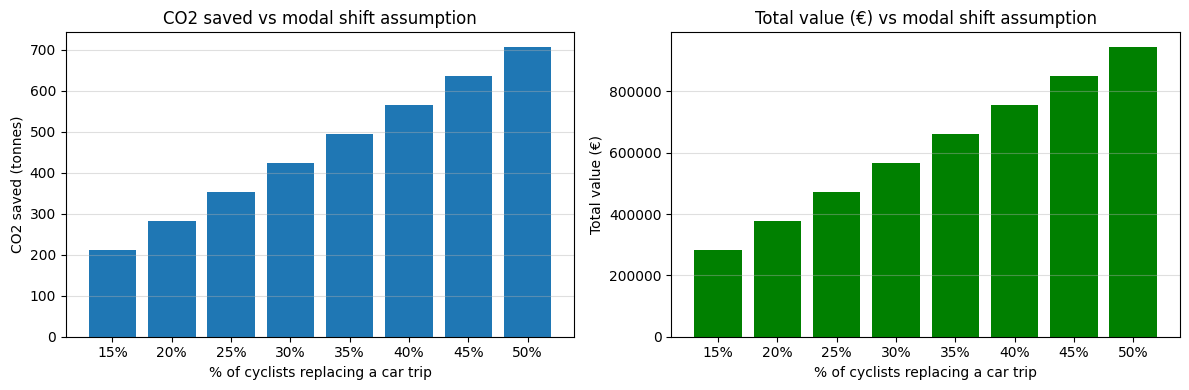


Central estimate (35% modal shift):
  CO2 saved    : 495.1 tonnes
  Total value  : €661,435

Range (15% to 50%):
  CO2 saved    : 212.2 – 707.4 tonnes
  Total value  : €283,472 – €944,907


In [44]:
sensitivity_rows = []

for modal_rate in [0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    constants_var = {**IMPACT_CONSTANTS, "modal_shift_rate": modal_rate}
    total_co2_tonnes = (
        impact_df["predicted_count"].sum() *
        modal_rate *
        IMPACT_CONSTANTS["avg_trip_km"] *
        IMPACT_CONSTANTS["co2_per_km_g"] / 1_000_000
    )
    total_value = (
        impact_df["predicted_count"].sum() *
        modal_rate *
        IMPACT_CONSTANTS["avg_trip_km"] * (
            IMPACT_CONSTANTS["fuel_per_km_l"] * IMPACT_CONSTANTS["fuel_price_eur"] +
            IMPACT_CONSTANTS["co2_per_km_g"] / 1_000_000 * IMPACT_CONSTANTS["co2_price_per_tonne_eur"] +
            IMPACT_CONSTANTS["health_cost_per_km_eur"]
        )
    )
    sensitivity_rows.append({
        "modal_shift_rate": f"{modal_rate*100:.0f}%",
        "co2_saved_tonnes": round(total_co2_tonnes, 1),
        "total_value_eur":  round(total_value, 0),
    })

sensitivity_df = pd.DataFrame(sensitivity_rows)
display(sensitivity_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(sensitivity_df["modal_shift_rate"], sensitivity_df["co2_saved_tonnes"])
axes[0].set_title("CO2 saved vs modal shift assumption")
axes[0].set_xlabel("% of cyclists replacing a car trip")
axes[0].set_ylabel("CO2 saved (tonnes)")
axes[0].grid(axis="y", alpha=0.4)

axes[1].bar(sensitivity_df["modal_shift_rate"], sensitivity_df["total_value_eur"], color="green")
axes[1].set_title("Total value (€) vs modal shift assumption")
axes[1].set_xlabel("% of cyclists replacing a car trip")
axes[1].set_ylabel("Total value (€)")
axes[1].grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.show()

print("\nCentral estimate (35% modal shift):")
central = sensitivity_df[sensitivity_df["modal_shift_rate"] == "35%"].iloc[0]
print(f"  CO2 saved    : {central['co2_saved_tonnes']} tonnes")
print(f"  Total value  : €{central['total_value_eur']:,.0f}")
print(f"\nRange ({sensitivity_df['modal_shift_rate'].iloc[0]} to {sensitivity_df['modal_shift_rate'].iloc[-1]}):")
print(f"  CO2 saved    : {sensitivity_df['co2_saved_tonnes'].min()} – {sensitivity_df['co2_saved_tonnes'].max()} tonnes")
print(f"  Total value  : €{sensitivity_df['total_value_eur'].min():,.0f} – €{sensitivity_df['total_value_eur'].max():,.0f}")

This figure shows a sensitivity analysis for the environmental-impact calculation. As the assumed percentage of cyclists replacing car trips increases from 15% to 50%, both the estimated CO₂ saved and the total monetary value saved increase almost linearly.

This means the final environmental benefit strongly depends on the modal-shift assumption: if only a small share of cycling trips replace car trips, the estimated impact is lower, but if a larger share replaces car use, the CO₂ and economic savings become much higher

In [45]:
impact_df.to_csv(f"{results_dir}/impact_hourly.csv", index=False)
daily_impact.to_csv(f"{results_dir}/impact_daily.csv", index=False)
site_impact.to_csv(f"{results_dir}/impact_by_site.csv", index=False)
yearly_impact.to_csv(f"{results_dir}/impact_yearly.csv", index=False)
sensitivity_df.to_csv(f"{results_dir}/impact_sensitivity.csv", index=False)

print("Impact files saved:")
print("  impact_hourly.csv")
print("  impact_daily.csv")
print("  impact_by_site.csv")
print("  impact_yearly.csv")
print("  impact_sensitivity.csv")

Impact files saved:
  impact_hourly.csv
  impact_daily.csv
  impact_by_site.csv
  impact_yearly.csv
  impact_sensitivity.csv


In [46]:

dow_impact = (
    impact_df
    .groupby(impact_df["datetime_hour"].dt.dayofweek)
    .agg(
        avg_daily_cyclists  = ("predicted_count",   "mean"),
        avg_co2_saved_kg    = ("co2_saved_kg",      "mean"),
        avg_value_eur       = ("total_value_eur",   "mean"),
    )
    .reset_index()
    .rename(columns={"datetime_hour": "day_of_week"})
)
dow_impact["day_name"] = dow_impact["day_of_week"].map({
    0:"Monday", 1:"Tuesday", 2:"Wednesday",
    3:"Thursday", 4:"Friday", 5:"Saturday", 6:"Sunday"
})
display(dow_impact[["day_name", "avg_daily_cyclists", "avg_co2_saved_kg", "avg_value_eur"]])

,day_name,avg_daily_cyclists,avg_co2_saved_kg,avg_value_eur
0,Monday,15.226271,2.558010,3.417051
1,Tuesday,17.250609,2.898105,3.871361
2,Wednesday,17.829097,2.995270,4.001160
3,Thursday,16.303914,2.739066,3.658911
4,Friday,15.849950,2.662787,3.557020
5,Saturday,10.155476,1.706098,2.279057
6,Sunday,7.962011,1.337615,1.786821


In [47]:
weekday_avg = dow_impact[dow_impact["day_of_week"] < 5]["avg_value_eur"].mean()
weekend_avg = dow_impact[dow_impact["day_of_week"] >= 5]["avg_value_eur"].mean()

print(f"Average value per hour (weekday): €{weekday_avg:.2f}")
print(f"Average value per hour (weekend): €{weekend_avg:.2f}")
print(f"Weekday generates {weekday_avg/weekend_avg:.1f}× more value than weekend")

Average value per hour (weekday): €3.70
Average value per hour (weekend): €2.03
Weekday generates 1.8× more value than weekend


In [48]:
# 2026 test covers Jan-Feb (roughly 59 days)
test_days = (impact_df["datetime_hour"].max() - impact_df["datetime_hour"].min()).days + 1
total_value_test = impact_df["total_value_eur"].sum()

# Annualise — cycling is seasonal so scale up for summer months
# Belgian cycling typically peaks May-Sep; Jan-Feb is low season
# Apply a seasonal uplift factor of ~1.4 based on typical Belgian patterns
seasonal_uplift = 1.4
annual_value_estimate = (total_value_test / test_days) * 365 * seasonal_uplift

print(f"Test period        : {test_days} days")
print(f"Total value (test) : €{total_value_test:,.0f}")
print(f"Daily average      : €{total_value_test/test_days:,.0f}")
print(f"Annual estimate    : €{annual_value_estimate:,.0f}  (with {seasonal_uplift}× seasonal uplift)")

Test period        : 59 days
Total value (test) : €661,430
Daily average      : €11,211
Annual estimate    : €5,728,655  (with 1.4× seasonal uplift)


In [49]:
total_cyclists = impact_df["predicted_count"].sum()
total_value    = impact_df["total_value_eur"].sum()

print(f"Value per predicted cyclist trip : €{total_value/total_cyclists:.4f}")
print(f"Value per 1,000 trips            : €{1000*total_value/total_cyclists:.2f}")

Value per predicted cyclist trip : €0.2244
Value per 1,000 trips            : €224.42


In [ ]:

# Extract only municipalities/cities present in cycling data
# Use final prediction dataframe
prediction_df = test_2026_results.copy()

print(prediction_df.columns)

# Check which column contains city/municipality information
# Usually it should be "municipality"
city_col = "municipality"

site_cities = (
    prediction_df[city_col]
    .dropna()
    .astype(str)
    .str.strip()
    .drop_duplicates()
    .sort_values()
    .reset_index(drop=True)
)

print("Number of municipalities in our cycling data:", len(site_cities))
display(site_cities.to_frame(name="municipality"))

# Save this list, useful for manual checking
site_cities.to_csv(f"{results_dir}/municipalities_in_cycling_data.csv", index=False)

Index(['site_id', 'datetime_hour', 'count', 'year', 'month', 'day', 'hour',
       'day_of_week', 'is_weekend', 'lat', 'lon', 'site_name', 'municipality',
       'temperature_2m', 'precipitation', 'wind_speed_10m',
       'shortwave_radiation', 'relative_humidity_2m', 'school_count',
       'park_count', 'station_count', 'dist_nearest_school',
       'dist_nearest_station', 'is_holiday', 'is_pre_holiday', 'hour_sin',
       'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'site_code',
       'lag_1', 'lag_24', 'lag_168', 'rolling_24_mean', 'rolling_168_mean',
       'predicted_count', 'actual_count', 'residual', 'absolute_error'],
      dtype='object')
Number of municipalities in our cycling data: 70


,municipality
0,Aalst
1,Aalter
2,Aarschot
3,Ardooie
4,As
...,...
65,Wervik
66,Westerlo
67,Zaventem
68,Zele


In [ ]:

# download Statbel population data directly


import pandas as pd
import requests
from pathlib import Path

statbel_pop_url = "https://statbel.fgov.be/sites/default/files/files/opendata/bevolking%20naar%20woonplaats%2C%20nationaliteit%20burgelijke%20staat%20%2C%20leeftijd%20en%20geslacht/TF_SOC_POP_STRUCT_2025.xlsx"

statbel_file = Path(results_dir) / "statbel_population_2025.xlsx"

response = requests.get(statbel_pop_url)
response.raise_for_status()

with open(statbel_file, "wb") as f:
    f.write(response.content)

print("Downloaded:", statbel_file)

Downloaded: /content/drive/MyDrive/Colab Notebooks/results/statbel_population_2025.xlsx


In [ ]:

# read Statbel file


pop_raw = pd.read_excel(statbel_file)

print("Shape:", pop_raw.shape)
print("Columns:")
print(pop_raw.columns)

display(pop_raw.head())

Shape: (466822, 21)
Columns:
Index(['CD_REFNIS', 'TX_DESCR_NL', 'TX_DESCR_FR', 'CD_DSTR_REFNIS',
       'TX_ADM_DSTR_DESCR_NL', 'TX_ADM_DSTR_DESCR_FR', 'CD_PROV_REFNIS',
       'TX_PROV_DESCR_NL', 'TX_PROV_DESCR_FR', 'CD_RGN_REFNIS',
       'TX_RGN_DESCR_NL', 'TX_RGN_DESCR_FR', 'CD_SEX', 'CD_NATLTY',
       'TX_NATLTY_NL', 'TX_NATLTY_FR', 'CD_CIV_STS', 'TX_CIV_STS_NL',
       'TX_CIV_STS_FR', 'CD_AGE', 'MS_POPULATION'],
      dtype='object')


,CD_REFNIS,TX_DESCR_NL,TX_DESCR_FR,CD_DSTR_REFNIS,TX_ADM_DSTR_DESCR_NL,TX_ADM_DSTR_DESCR_FR,CD_PROV_REFNIS,TX_PROV_DESCR_NL,TX_PROV_DESCR_FR,CD_RGN_REFNIS,TX_RGN_DESCR_NL,TX_RGN_DESCR_FR,CD_SEX,CD_NATLTY,TX_NATLTY_NL,TX_NATLTY_FR,CD_CIV_STS,TX_CIV_STS_NL,TX_CIV_STS_FR,CD_AGE,MS_POPULATION
0,11001,Aartselaar,Aartselaar,11000,Arrondissement Antwerpen,Arrondissement d’Anvers,10000,Provincie Antwerpen,Province d’Anvers,2000,Vlaams Gewest,Région flamande,F,BEL,Belgen,Belges,4,Gescheiden,Divorcé,67,14
1,11001,Aartselaar,Aartselaar,11000,Arrondissement Antwerpen,Arrondissement d’Anvers,10000,Provincie Antwerpen,Province d’Anvers,2000,Vlaams Gewest,Région flamande,F,BEL,Belgen,Belges,4,Gescheiden,Divorcé,93,1
2,11001,Aartselaar,Aartselaar,11000,Arrondissement Antwerpen,Arrondissement d’Anvers,10000,Provincie Antwerpen,Province d’Anvers,2000,Vlaams Gewest,Région flamande,F,BEL,Belgen,Belges,4,Gescheiden,Divorcé,81,3
3,11001,Aartselaar,Aartselaar,11000,Arrondissement Antwerpen,Arrondissement d’Anvers,10000,Provincie Antwerpen,Province d’Anvers,2000,Vlaams Gewest,Région flamande,M,BEL,Belgen,Belges,4,Gescheiden,Divorcé,67,12
4,11001,Aartselaar,Aartselaar,11000,Arrondissement Antwerpen,Arrondissement d’Anvers,10000,Provincie Antwerpen,Province d’Anvers,2000,Vlaams Gewest,Région flamande,F,BEL,Belgen,Belges,4,Gescheiden,Divorcé,68,22


In [56]:
statbel_pop = (
    pop_raw
    .groupby(["CD_REFNIS", "TX_DESCR_NL"], as_index=False)["MS_POPULATION"]
    .sum()
    .rename(columns={
        "CD_REFNIS": "refnis_code",
        "TX_DESCR_NL": "municipality_statbel",
        "MS_POPULATION": "population"
    })
)

print("Number of municipalities in Statbel:", statbel_pop.shape[0])
display(statbel_pop.head())

Number of municipalities in Statbel: 565


,refnis_code,municipality_statbel,population
0,11001,Aartselaar,15093
1,11002,Antwerpen,562002
2,11004,Boechout,14084
3,11005,Boom,19699
4,11008,Brasschaat,38416


In [57]:
import unicodedata
import re
import numpy as np

def normalize_name(x):
    if pd.isna(x):
        return np.nan

    x = str(x).strip().lower()
    x = unicodedata.normalize("NFKD", x)
    x = "".join(c for c in x if not unicodedata.combining(c))
    x = re.sub(r"[^a-z0-9]+", " ", x)
    x = re.sub(r"\s+", " ", x).strip()
    return x

In [58]:

# Match cycling municipalities with Statbel municipalities


site_cities_df["municipality_norm"] = site_cities_df["municipality"].apply(normalize_name)
statbel_pop["municipality_norm"] = statbel_pop["municipality_statbel"].apply(normalize_name)

city_context = site_cities_df.merge(
    statbel_pop,
    on="municipality_norm",
    how="left"
)

display(city_context.head())

,municipality,municipality_norm,refnis_code,municipality_statbel,population
0,Aalst,aalst,41002.0,Aalst,92131.0
1,Aalter,aalter,44084.0,Aalter,29830.0
2,Aarschot,aarschot,24001.0,Aarschot,31514.0
3,Ardooie,ardooie,37020.0,Ardooie,9514.0
4,As,as,71002.0,As,8298.0


In [60]:

# Manual correction for 2025 merged municipalities / non-standard labels


name_corrections = {
    # 2025 Flemish municipality mergers
    "beveren": "beveren kruibeke zwijndrecht",
    "bilzen": "bilzen hoeselt",
    "melle": "merelbeke melle",
    "meulebeke": "tielt",
    "nazareth": "nazareth de pinte",
    "tongeren": "tongeren borgloon",

    # non-standard cycling-data labels
    # Check with lat/lon if these are not exactly correct
    "district leuven": "leuven",
    "district vilvoorde gewestwegen": "vilvoorde",
}

site_cities_df["municipality_norm"] = (
    site_cities_df["municipality"]
    .apply(normalize_name)
    .replace(name_corrections)
)

statbel_pop["municipality_norm"] = (
    statbel_pop["municipality_statbel"]
    .apply(normalize_name)
)

city_context = site_cities_df.merge(
    statbel_pop,
    on="municipality_norm",
    how="left"
)

missing_matches = city_context[
    city_context["population"].isna()
][["municipality"]].drop_duplicates()

print("Missing matches after correction:", len(missing_matches))
display(missing_matches)

Missing matches after correction: 0


,municipality


In [61]:
missing_matches = city_context[
    city_context["population"].isna()
][["municipality"]].drop_duplicates()

print("Missing matches:", len(missing_matches))
display(missing_matches)

Missing matches: 0


,municipality


In [62]:
city_context_final = city_context[
    [
        "municipality",
        "municipality_statbel",
        "refnis_code",
        "population"
    ]
].drop_duplicates()

display(city_context_final)

city_context_final.to_csv(
    f"{results_dir}/belgium_city_context_filtered.csv",
    index=False
)

,municipality,municipality_statbel,refnis_code,population
0,Aalst,Aalst,41002,92131
1,Aalter,Aalter,44084,29830
2,Aarschot,Aarschot,24001,31514
3,Ardooie,Ardooie,37020,9514
4,As,As,71002,8298
...,...,...,...,...
65,Wervik,Wervik,33029,19207
66,Westerlo,Westerlo,13049,25691
67,Zaventem,Zaventem,23094,37271
68,Zele,Zele,42028,21521


In [63]:
city_context_path = f"{results_dir}/belgium_city_context_filtered.csv"

city_context = pd.read_csv(city_context_path)

print(city_context.shape)
display(city_context.head())

print("Missing population:", city_context["population"].isna().sum())

(70, 4)


,municipality,municipality_statbel,refnis_code,population
0,Aalst,Aalst,41002,92131
1,Aalter,Aalter,44084,29830
2,Aarschot,Aarschot,24001,31514
3,Ardooie,Ardooie,37020,9514
4,As,As,71002,8298


Missing population: 0


In [ ]:

# merge municipality population into 2026 prediction results


impact_base = test_2026_results.copy()

impact_base = impact_base.merge(
    city_context,
    on="municipality",
    how="left"
)

print("Shape after merge:", impact_base.shape)
print("Missing population after merge:", impact_base["population"].isna().sum())

display(
    impact_base[
        ["site_id", "municipality", "municipality_statbel", "population",
         "datetime_hour", "predicted_count", "actual_count"]
    ].head()
)

Shape after merge: (205320, 44)
Missing population after merge: 1416


,site_id,municipality,municipality_statbel,population,datetime_hour,predicted_count,actual_count
0,1,Machelen,Machelen,16784.0,2026-01-01 00:00:00,0.419302,3.0
1,1,Machelen,Machelen,16784.0,2026-01-01 01:00:00,1.258577,1.0
2,1,Machelen,Machelen,16784.0,2026-01-01 02:00:00,0.672360,4.0
3,1,Machelen,Machelen,16784.0,2026-01-01 03:00:00,0.817200,1.0
4,1,Machelen,Machelen,16784.0,2026-01-01 04:00:00,0.692364,3.0


In [ ]:

# impact assumptions for government reporting

IMPACT_FACTORS = {
    # Bicycle count to estimated unique bicycle trips
    "trip_correction_factor": 0.80,

    # Share of bicycle trips assumed to replace car trips
    "modal_shift_car": 0.35,

    # Average replaced car-trip distance
    "avg_trip_km": 5.0,

    # Car CO2 emission factor
    "car_co2_g_per_km": 120,

    # Fuel consumption
    "fuel_l_per_km": 0.07,

    # Fuel price
    "fuel_price_eur_per_l": 1.75,

    # Carbon value
    "co2_price_eur_per_tonne": 65,

    # Additional avoided external cost per car-km
    "health_external_cost_eur_per_km": 0.03,
}

In [69]:

# Compute fuel, CO2 and economic value from predicted cycling

impact_df = impact_base.copy()

impact_df["datetime_hour"] = pd.to_datetime(impact_df["datetime_hour"])
impact_df["date"] = impact_df["datetime_hour"].dt.date
impact_df["hour"] = impact_df["datetime_hour"].dt.hour
impact_df["day_of_week"] = impact_df["datetime_hour"].dt.dayofweek
impact_df["is_weekend"] = impact_df["day_of_week"].isin([5, 6]).astype(int)
impact_df["is_peak_hour"] = impact_df["hour"].isin([7, 8, 9, 16, 17, 18]).astype(int)

# 1. Predicted bicycle passages → estimated unique bicycle trips
impact_df["estimated_bike_trips"] = (
    impact_df["predicted_count"] * IMPACT_FACTORS["trip_correction_factor"]
)

# 2. Estimated bicycle trips replacing car trips
impact_df["car_trips_replaced"] = (
    impact_df["estimated_bike_trips"] * IMPACT_FACTORS["modal_shift_car"]
)

# 3. Avoided car kilometres
impact_df["km_not_driven"] = (
    impact_df["car_trips_replaced"] * IMPACT_FACTORS["avg_trip_km"]
)

# 4. CO2 saving
impact_df["co2_saved_kg"] = (
    impact_df["km_not_driven"] * IMPACT_FACTORS["car_co2_g_per_km"] / 1000
)

impact_df["co2_saved_tonnes"] = impact_df["co2_saved_kg"] / 1000

# 5. Fuel saving
impact_df["fuel_saved_litres"] = (
    impact_df["km_not_driven"] * IMPACT_FACTORS["fuel_l_per_km"]
)

impact_df["fuel_cost_saved_eur"] = (
    impact_df["fuel_saved_litres"] * IMPACT_FACTORS["fuel_price_eur_per_l"]
)

# 6. Carbon value
impact_df["carbon_value_eur"] = (
    impact_df["co2_saved_tonnes"] * IMPACT_FACTORS["co2_price_eur_per_tonne"]
)

# 7. Additional external value
impact_df["external_cost_saved_eur"] = (
    impact_df["km_not_driven"] * IMPACT_FACTORS["health_external_cost_eur_per_km"]
)

# 8. Total value
impact_df["total_value_eur"] = (
    impact_df["fuel_cost_saved_eur"]
    + impact_df["carbon_value_eur"]
    + impact_df["external_cost_saved_eur"]
)

display(
    impact_df[
        [
            "municipality", "datetime_hour", "predicted_count",
            "estimated_bike_trips", "car_trips_replaced",
            "km_not_driven", "fuel_saved_litres",
            "co2_saved_kg", "total_value_eur"
        ]
    ].head()
)

,municipality,datetime_hour,predicted_count,estimated_bike_trips,car_trips_replaced,km_not_driven,fuel_saved_litres,co2_saved_kg,total_value_eur
0,Machelen,2026-01-01 00:00:00,0.419302,0.335442,0.117405,0.587023,0.041092,0.070443,0.094100
1,Machelen,2026-01-01 01:00:00,1.258577,1.006862,0.352402,1.762008,0.123341,0.211441,0.282450
2,Machelen,2026-01-01 02:00:00,0.672360,0.537888,0.188261,0.941304,0.065891,0.112956,0.150891
3,Machelen,2026-01-01 03:00:00,0.817200,0.653760,0.228816,1.144080,0.080086,0.137290,0.183396
4,Machelen,2026-01-01 04:00:00,0.692364,0.553891,0.193862,0.969309,0.067852,0.116317,0.155380


In [70]:

# City-wise / municipality-wise government impact summary

city_impact = (
    impact_df
    .groupby(["municipality", "municipality_statbel"])
    .agg(
        population=("population", "first"),
        site_count=("site_id", "nunique"),

        total_predicted_cyclists=("predicted_count", "sum"),
        estimated_bike_trips=("estimated_bike_trips", "sum"),
        car_trips_replaced=("car_trips_replaced", "sum"),
        km_not_driven=("km_not_driven", "sum"),

        fuel_saved_litres=("fuel_saved_litres", "sum"),
        co2_saved_kg=("co2_saved_kg", "sum"),
        co2_saved_tonnes=("co2_saved_tonnes", "sum"),

        fuel_cost_saved_eur=("fuel_cost_saved_eur", "sum"),
        carbon_value_eur=("carbon_value_eur", "sum"),
        external_cost_saved_eur=("external_cost_saved_eur", "sum"),
        total_value_eur=("total_value_eur", "sum"),

        weekday_value_eur=(
            "total_value_eur",
            lambda x: x[impact_df.loc[x.index, "is_weekend"] == 0].sum()
        ),
        weekend_value_eur=(
            "total_value_eur",
            lambda x: x[impact_df.loc[x.index, "is_weekend"] == 1].sum()
        ),
        peak_hour_value_eur=(
            "total_value_eur",
            lambda x: x[impact_df.loc[x.index, "is_peak_hour"] == 1].sum()
        ),
    )
    .reset_index()
)

city_impact["value_per_capita_eur"] = (
    city_impact["total_value_eur"] / city_impact["population"]
)

city_impact["co2_saved_kg_per_capita"] = (
    city_impact["co2_saved_kg"] / city_impact["population"]
)

city_impact["weekday_weekend_ratio"] = (
    city_impact["weekday_value_eur"] / (city_impact["weekend_value_eur"] + 1e-9)
)

city_impact = city_impact.sort_values("total_value_eur", ascending=False)

display(
    city_impact[
        [
            "municipality", "population", "site_count",
            "total_predicted_cyclists", "fuel_saved_litres",
            "co2_saved_tonnes", "total_value_eur",
            "value_per_capita_eur", "co2_saved_kg_per_capita"
        ]
    ].head(20)
)

,municipality,population,site_count,total_predicted_cyclists,fuel_saved_litres,co2_saved_tonnes,total_value_eur,value_per_capita_eur,co2_saved_kg_per_capita
39,Leuven,104906.0,5,433623.676166,42495.120264,72.848778,97313.825405,0.927629,0.694420
36,Kortrijk,80776.0,5,309128.417050,30294.584871,51.933574,69374.599354,0.858852,0.642933
26,Hasselt,90249.0,3,245402.239699,24049.419490,41.227576,55073.170633,0.610236,0.456820
23,Gent,272657.0,4,165351.934544,16204.489585,27.779125,37108.281150,0.136099,0.101883
13,Brugge,120283.0,5,112359.675265,11011.248176,18.876425,25215.758323,0.209637,0.156933
15,Dendermonde,47539.0,2,88872.316025,8709.486970,14.930549,19944.725162,0.419544,0.314069
66,Westerlo,25691.0,4,80211.222714,7860.699826,13.475485,18001.002601,0.700673,0.524522
48,Mechelen,89655.0,2,79923.017242,7832.455690,13.427067,17936.323530,0.200059,0.149764
10,Brasschaat,38416.0,2,79043.130360,7746.226775,13.279246,17738.859315,0.461757,0.345670
69,Zemst,23369.0,1,78214.194928,7664.991103,13.139985,17552.829626,0.751116,0.562283


In [71]:

# Site-level priority ranking for government planning


site_impact = (
    impact_df
    .groupby(["site_id", "site_name", "municipality"])
    .agg(
        lat=("lat", "first"),
        lon=("lon", "first"),
        population=("population", "first"),

        total_predicted_cyclists=("predicted_count", "sum"),
        estimated_bike_trips=("estimated_bike_trips", "sum"),
        car_trips_replaced=("car_trips_replaced", "sum"),
        km_not_driven=("km_not_driven", "sum"),

        fuel_saved_litres=("fuel_saved_litres", "sum"),
        co2_saved_kg=("co2_saved_kg", "sum"),
        total_value_eur=("total_value_eur", "sum"),

        peak_hour_value_eur=(
            "total_value_eur",
            lambda x: x[impact_df.loc[x.index, "is_peak_hour"] == 1].sum()
        ),
        avg_absolute_error=("absolute_error", "mean"),
    )
    .reset_index()
)

site_impact["co2_saved_tonnes"] = site_impact["co2_saved_kg"] / 1000

def normalize_series(s):
    return (s - s.min()) / (s.max() - s.min() + 1e-9)

site_impact["priority_score"] = (
    0.30 * normalize_series(site_impact["co2_saved_kg"])
    + 0.25 * normalize_series(site_impact["total_value_eur"])
    + 0.20 * normalize_series(site_impact["peak_hour_value_eur"])
    + 0.15 * normalize_series(site_impact["fuel_saved_litres"])
    + 0.10 * normalize_series(site_impact["avg_absolute_error"])
)

site_impact = site_impact.sort_values("priority_score", ascending=False)
site_impact["priority_rank"] = range(1, len(site_impact) + 1)

display(
    site_impact[
        [
            "priority_rank", "site_id", "site_name", "municipality",
            "total_predicted_cyclists", "fuel_saved_litres",
            "co2_saved_tonnes", "total_value_eur",
            "priority_score"
        ]
    ].head(20)
)

,priority_rank,site_id,site_name,municipality,total_predicted_cyclists,fuel_saved_litres,co2_saved_tonnes,total_value_eur,priority_score
103,1,107,leuven totem,Leuven,208955.493939,20477.638406,35.104523,46893.791950,0.988108
136,2,143,Eco Display Classic Budastraat,Kortrijk,197194.380741,19325.049313,33.128656,44254.362926,0.947426
67,3,69,Leuven teller 1,Leuven,125909.766267,12339.157094,21.152841,28256.669746,0.597765
121,4,125,Dendermonde totem,Dendermonde,88775.576223,8700.006470,14.914297,19923.014816,0.448840
135,5,140,Hasselt ring,Hasselt,85632.118192,8391.947583,14.386196,19217.559965,0.410195
132,6,137,Hasselt-Kempische brug,Hasselt,84423.682212,8273.520857,14.183179,18946.362762,0.410021
105,7,109,Zemst,Zemst,78214.194928,7664.991103,13.139985,17552.829626,0.400945
133,8,138,Hasselt-Kempische brug,Hasselt,75346.439295,7383.951051,12.658202,16909.247906,0.359878
96,9,100,Mechelen teller 2,Mechelen,74722.213525,7322.776925,12.553332,16769.159159,0.353118
115,10,119,Gent teller 2,Gent,57374.311403,5622.682517,9.638884,12875.942965,0.278532


In [73]:
impact_df.to_csv(
    f"{results_dir}/site_hour_impact.csv",
    index=False
)

city_impact.to_csv(
    f"{results_dir}/city_impact_summary.csv",
    index=False
)

site_impact.to_csv(
    f"{results_dir}/site_priority.csv",
    index=False
)

print("Saved dashboard files:")
print(f"{results_dir}/site_hour_impact.csv")
print(f"{results_dir}/city_impact_summary.csv")
print(f"{results_dir}/site_priority.csv")

Saved dashboard files:
/content/drive/MyDrive/Colab Notebooks/results/site_hour_impact.csv
/content/drive/MyDrive/Colab Notebooks/results/city_impact_summary.csv
/content/drive/MyDrive/Colab Notebooks/results/site_priority.csv


This result summarizes the economic/environmental value estimated for the 2026 test period.

The model estimates that during the 59-day test period, cycling generated a total value of about €661,430, which equals roughly €11,211 per day. When this daily value is scaled up to a full year and adjusted with a 1.4× seasonal uplift to account for higher cycling activity in warmer months, the annual estimated value becomes about €5.73 million.

The weekday/weekend comparison shows that cycling creates more value during weekdays:

Weekday average value per hour: €3.70
Weekend average value per hour: €2.03

This means weekdays generate about 1.8× more value than weekends, likely because weekday cycling is more strongly linked to commuting, school, work, and routine travel. In simple terms, the economic benefit of cycling is highest during regular weekday mobility patterns.